<a href="https://colab.research.google.com/github/Armandohaj/Proyecto_FIFA_Grupo7/blob/main/Etapa2_FIFA_5_Facts_Snowflake_GITHUB_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Etapa 2 — Modelado dimensional FIFA 15 a FIFA 24

## Objetivo

Construir un modelo dimensional para responder las cinco preguntas de negocio de la Etapa 2.

La solución utiliza **cinco tablas de hechos**, una por pregunta de negocio, y dimensiones compartidas. La relación `League → Region` se normaliza con enfoque **Snowflake**. Al compartir dimensiones entre varias tablas de hechos, el modelo completo funciona como una **constelación de hechos (Galaxy / Fact Constellation)**.

### Principio de diseño

La granularidad **no es universal para todo el proyecto**. Cada Fact Table tiene su propia granularidad según la pregunta que debe responder.

`player_id` y `season` se conservan durante la preparación de datos para trazabilidad y controles de calidad de la fuente, pero **no definen la granularidad de las tablas de hechos finales**.

### Ejecución reproducible

Este notebook está preparado para ejecutarse en **Google Colab sin depender del Google Drive de ningún integrante y sin instalar paquetes adicionales**.

Archivos de entrada requeridos:

- `fifa_15_24_limpio.csv`
- `referencias_modelado_etapa2.xlsx`


In [3]:
from pathlib import Path
import hashlib
import re
import shutil
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 40)


## Entrada automática desde GitHub Releases

Esta versión está preparada para una entrega reproducible en Google Colab.

El profesor solo debe abrir el notebook y ejecutar **Run all**.

El notebook:

1. No monta Google Drive.
2. No pide subir archivos manualmente.
3. Descarga automáticamente las dos entradas desde la Release `v1.0-etapa2` del repositorio público del grupo.
4. Trabaja únicamente dentro de `/content/Proyecto_FIFA_Etapa2`.
5. Nunca modifica los archivos de entrada.
6. Genera todos los resultados en una carpeta de salida independiente.


In [4]:
from urllib.request import Request, urlopen

# ============================================================
# ENTRADAS PÚBLICAS DE LA ETAPA 2
# ============================================================
REPO_OWNER = "Armandohaj"
REPO_NAME = "Proyecto_FIFA_Grupo7"
RELEASE_TAG = "v1.0-etapa2"

RELEASE_BASE_URL = (
    f"https://github.com/{REPO_OWNER}/{REPO_NAME}/releases/download/{RELEASE_TAG}"
)

URL_FIFA = f"{RELEASE_BASE_URL}/fifa_15_24_limpio.csv"
URL_REFERENCIAS = f"{RELEASE_BASE_URL}/referencias_modelado_etapa2.xlsx"

# ============================================================
# CARPETAS TEMPORALES DE COLAB
# ============================================================
BASE_DIR = Path("/content/Proyecto_FIFA_Etapa2")
INPUT_DIR = BASE_DIR / "input"
OUTPUT_DIR = BASE_DIR / "output"
DIM_DIR = OUTPUT_DIR / "dimensiones"
FACT_DIR = OUTPUT_DIR / "facts"
QUERY_DIR = OUTPUT_DIR / "consultas"
REPORT_DIR = OUTPUT_DIR / "reportes"
AUDIT_DIR = OUTPUT_DIR / "auditorias"

# Alias para conservar compatibilidad con la preparación de datos.
PROJECT_DIR = BASE_DIR
DATA_DIR = BASE_DIR
RAW_DIR = INPUT_DIR
PROCESSED_DIR = OUTPUT_DIR
ETAPA2_DIR = OUTPUT_DIR
NOTEBOOKS_DIR = BASE_DIR

INPUT_DIR.mkdir(parents=True, exist_ok=True)

# La salida se regenera en cada ejecución; la entrada queda separada.
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for carpeta in [OUTPUT_DIR, DIM_DIR, FACT_DIR, QUERY_DIR, REPORT_DIR, AUDIT_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

# ============================================================
# DESCARGA AUTOMÁTICA DESDE GITHUB RELEASES
# ============================================================
def descargar_archivo(url, destino):
    print(f"Descargando {destino.name}...")

    request = Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    try:
        with urlopen(request, timeout=180) as response:
            contenido = response.read()
    except Exception as exc:
        raise RuntimeError(
            f"No se pudo descargar {destino.name}.\n"
            f"URL utilizada: {url}\n"
            "Comprueba que la Release siga publicada y que el repositorio sea público."
        ) from exc

    if len(contenido) == 0:
        raise RuntimeError(f"La descarga de {destino.name} quedó vacía")

    destino.write_bytes(contenido)
    print(f"✓ {destino.name} ({len(contenido):,} bytes)")


ARCHIVO_ENTRADA = INPUT_DIR / "fifa_15_24_limpio.csv"
ARCHIVO_REFERENCIAS = INPUT_DIR / "referencias_modelado_etapa2.xlsx"

descargar_archivo(URL_FIFA, ARCHIVO_ENTRADA)
descargar_archivo(URL_REFERENCIAS, ARCHIVO_REFERENCIAS)

# ============================================================
# VALIDACIONES BÁSICAS DE DESCARGA
# ============================================================
if ARCHIVO_ENTRADA.stat().st_size < 1_000_000:
    raise RuntimeError(
        "fifa_15_24_limpio.csv parece incompleto: el tamaño descargado es demasiado pequeño"
    )

if ARCHIVO_REFERENCIAS.stat().st_size < 1_000:
    raise RuntimeError(
        "referencias_modelado_etapa2.xlsx parece incompleto: el tamaño descargado es demasiado pequeño"
    )

# Un archivo XLSX válido es un contenedor ZIP y comienza con PK.
if ARCHIVO_REFERENCIAS.read_bytes()[:2] != b"PK":
    raise RuntimeError(
        "referencias_modelado_etapa2.xlsx no parece ser un archivo XLSX válido"
    )

# Huellas para demostrar que las entradas no cambian durante la ejecución.
huellas_entradas = {
    ruta: hashlib.sha256(ruta.read_bytes()).hexdigest()
    for ruta in [ARCHIVO_ENTRADA, ARCHIVO_REFERENCIAS]
}

print("\nEntradas descargadas correctamente desde GitHub Releases")
print("✓", ARCHIVO_ENTRADA.name)
print("✓", ARCHIVO_REFERENCIAS.name)
print("\nRepositorio:", f"https://github.com/{REPO_OWNER}/{REPO_NAME}")
print("Release:", f"https://github.com/{REPO_OWNER}/{REPO_NAME}/releases/tag/{RELEASE_TAG}")
print("Carpeta de trabajo:", BASE_DIR)
print("Carpeta de salida:", OUTPUT_DIR)


Descargando fifa_15_24_limpio.csv...
✓ fifa_15_24_limpio.csv (39,397,672 bytes)
Descargando referencias_modelado_etapa2.xlsx...
✓ referencias_modelado_etapa2.xlsx (61,484 bytes)

Entradas descargadas correctamente desde GitHub Releases
✓ fifa_15_24_limpio.csv
✓ referencias_modelado_etapa2.xlsx

Repositorio: https://github.com/Armandohaj/Proyecto_FIFA_Grupo7
Release: https://github.com/Armandohaj/Proyecto_FIFA_Grupo7/releases/tag/v1.0-etapa2
Carpeta de trabajo: /content/Proyecto_FIFA_Etapa2
Carpeta de salida: /content/Proyecto_FIFA_Etapa2/output


### Referencias del modelo

`referencias_modelado_etapa2.xlsx` es el archivo de referencias utilizado para homologaciones, fuentes externas, excepciones justificadas y la relación explícita `League → Region`.

Primero se utilizan los datos y el historial disponible. Cuando el dataset no permite resolver una referencia de forma segura, se utiliza una fuente externa documentada.


In [5]:
referencias = pd.read_excel(
    ARCHIVO_REFERENCIAS,
    sheet_name=None
)

huellas_entradas[ARCHIVO_REFERENCIAS] = hashlib.sha256(
    ARCHIVO_REFERENCIAS.read_bytes()
).hexdigest()


def contiene_url(valor):
    return bool(
        re.search(
            r"https?://",
            str(valor),
            flags=re.IGNORECASE
        )
    )


hojas_obligatorias = {
    "league_aliases",
    "club_league_overrides",
    "player_club_overrides",
    "league_region",
    "scope_exclusions",
    "metadata",
    "club_identities",
    "label_compatibility",
    "fuentes_previas",
    "source_catalog"
}

faltantes = sorted(
    hojas_obligatorias - set(referencias)
)

if faltantes:
    raise ValueError(
        "Faltan hojas en el archivo de referencias: "
        + ", ".join(faltantes)
    )

claves_referencias = {
    "club_league_overrides": ["season", "club_original"],
    "player_club_overrides": ["season", "player_id"],
    "league_region": ["league_canonical"],
    "scope_exclusions": ["season", "player_id"],
    "club_identities": ["club_original", "league_canonical"],
    "label_compatibility": ["season", "club_original"],
    "fuentes_previas": ["club"],
    "source_catalog": ["source_key"]
}

problemas_referencias = []

for hoja, claves in claves_referencias.items():
    tabla = referencias[hoja]

    invalidas = (
        tabla.duplicated(claves, keep=False)
        | tabla[claves].isna().any(axis=1)
    )

    if invalidas.any():
        problemas_referencias.append(
            tabla.loc[invalidas].assign(hoja=hoja)
        )

aliases_directos = referencias["league_aliases"].query(
    "tipo_mapeo != 'ambiguo'"
)

duplicados_alias = aliases_directos.duplicated(
    "league_original",
    keep=False
)

if duplicados_alias.any():
    problemas_referencias.append(
        aliases_directos.loc[duplicados_alias].assign(
            hoja="league_aliases"
        )
    )

for hoja in [
    "club_league_overrides",
    "player_club_overrides",
    "club_identities"
]:
    tabla = referencias[hoja]
    sin_url = ~tabla["fuente"].map(contiene_url)

    if sin_url.any():
        problemas_referencias.append(
            tabla.loc[sin_url].assign(
                hoja=hoja,
                problema="Fuente externa sin URL"
            )
        )

region_ref = referencias["league_region"]

region_invalida = (
    region_ref["region"].isna()
    | region_ref["pais_referencia"].isna()
    | region_ref["pais_referencia"].astype(str).str.contains(
        "No especificado",
        case=False,
        na=False
    )
)

if region_invalida.any():
    problemas_referencias.append(
        region_ref.loc[region_invalida].assign(
            hoja="league_region",
            problema="País o región sin documentar"
        )
    )

fuentes_alias_validas = {
    "Dataset FIFA 15-23",
    "Historial FIFA 15-23"
}

alias_fuente_invalida = ~referencias["league_aliases"]["fuente"].isin(
    fuentes_alias_validas
)

if alias_fuente_invalida.any():
    problemas_referencias.append(
        referencias["league_aliases"].loc[
            alias_fuente_invalida
        ].assign(
            hoja="league_aliases",
            problema="Procedencia de alias no auditable"
        )
    )

if not referencias["scope_exclusions"]["fuente"].eq(
    "Regla de alcance de la Etapa 2"
).all():
    problemas_referencias.append(
        referencias["scope_exclusions"].assign(
            hoja="scope_exclusions",
            problema="Fuente de exclusión no metodológica"
        )
    )

if not referencias["label_compatibility"]["fuente"].eq(
    "Regla de compatibilidad de salida del modelo"
).all():
    problemas_referencias.append(
        referencias["label_compatibility"].assign(
            hoja="label_compatibility",
            problema="Compatibilidad sin regla explícita"
        )
    )

if problemas_referencias:
    pd.concat(
        problemas_referencias,
        ignore_index=True
    ).to_csv(
        ETAPA2_DIR / "conflictos_referencias.csv",
        index=False
    )

    raise ValueError(
        "El archivo de referencias contiene problemas; revisar conflictos_referencias.csv"
    )

resumen_referencias = pd.DataFrame({
    "hoja": list(referencias),
    "filas": [
        len(tabla)
        for tabla in referencias.values()
    ]
})

display(resumen_referencias)

print(
    "Archivo de referencias definitivo cargado y validado"
)


,hoja,filas
0,league_aliases,152
1,club_league_overrides,219
2,player_club_overrides,41
3,league_region,67
4,scope_exclusions,1
5,metadata,1
6,club_identities,8
7,label_compatibility,2
8,fuentes_previas,205
9,source_catalog,16


Archivo de referencias definitivo cargado y validado


## Carga de datos

Leemos el archivo limpio de Etapa 1. La Etapa 2 no vuelve a procesar los diez CSV originales.


In [6]:
df_etapa1 = pd.read_csv(
    ARCHIVO_ENTRADA,
    low_memory=False
)

df_etapa1.head()


,player_id,season,name,age,height_cm,weight_kg,position,overall,potential,value_eur,wage_eur,club,league,nationality,preferred_foot,pace,shooting,passing,dribbling,defending,physic,GrupoEdad,BrechaPotencial,ValorPorRating,RatioValorSalario,TipoPosicion,PerfilDesarrollo,FlagEdadInvalida,FlagRatingPotencial,FlagFinancieroAtipico
0,158023,15,L. Messi,27,169.0,67.0,CF,93,95.0,100500000.0,550000.0,FC Barcelona,Spain Primera Division,Argentina,Left,93.0,89.0,86.0,96.0,27.0,63.0,Prime,2.0,1.080645e+06,182.727273,Delantero,Prime_Alto_ProyeccionModerada,0,0,1
1,20801,15,Cristiano Ronaldo,29,185.0,80.0,"LW, LM",92,92.0,79000000.0,375000.0,Real Madrid CF,Spain Primera Division,Portugal,Right,93.0,93.0,81.0,91.0,32.0,79.0,Veteran,0.0,8.586957e+05,210.666667,Delantero,Veteran_Alto_SinBrecha,0,0,1
2,9014,15,A. Robben,30,180.0,80.0,"RM, LM, RW",90,90.0,54500000.0,275000.0,FC Bayern München,German 1. Bundesliga,Netherlands,Left,93.0,86.0,83.0,92.0,32.0,64.0,Veteran,0.0,6.055556e+05,198.181818,Mediocampista,Veteran_Alto_SinBrecha,0,0,1
3,41236,15,Z. Ibrahimović,32,195.0,95.0,ST,90,90.0,52500000.0,275000.0,Paris Saint-Germain,French Ligue 1,Sweden,Right,76.0,91.0,81.0,86.0,34.0,86.0,Veteran,0.0,5.833333e+05,190.909091,Delantero,Veteran_Alto_SinBrecha,0,0,1
4,167495,15,M. Neuer,28,193.0,92.0,GK,90,90.0,63500000.0,300000.0,FC Bayern München,German 1. Bundesliga,Germany,Right,NaN,NaN,NaN,NaN,NaN,NaN,Prime,0.0,7.055556e+05,211.666667,Portero,Prime_Alto_SinBrecha,0,0,1


### Tamaño de la base

Mostramos las filas, columnas y temporadas disponibles


In [7]:
print("Cantidad de filas", len(df_etapa1))
print("Cantidad de columnas", len(df_etapa1.columns))
print("Temporadas disponibles", sorted(df_etapa1["season"].dropna().unique()))


Cantidad de filas 178545
Cantidad de columnas 30
Temporadas disponibles [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


### Columnas necesarias

Revisamos que el archivo incluya las columnas usadas en esta etapa


In [8]:
columnas_necesarias = [
    "player_id",
    "season",
    "club",
    "league",
    "nationality",
    "GrupoEdad",
    "position",
    "TipoPosicion",
    "overall",
    "potential",
    "value_eur",
    "wage_eur"
]

columnas_faltantes = [
    columna
    for columna in columnas_necesarias
    if columna not in df_etapa1.columns
]

if len(columnas_faltantes) == 0:
    print("Todas las columnas necesarias están disponibles")
else:
    print("Columnas faltantes", columnas_faltantes)


Todas las columnas necesarias están disponibles


### Datos faltantes

Revisamos los faltantes de potencial, valor de mercado, salario, club y liga


In [9]:
columnas_revision_nulos = [
    "potential",
    "value_eur",
    "wage_eur",
    "club",
    "league"
]

revision_nulos = pd.DataFrame({
    "columna": columnas_revision_nulos,
    "nulos": [
        df_etapa1[columna].isna().sum()
        for columna in columnas_revision_nulos
    ]
})

revision_nulos


,columna,nulos
0,potential,15845
1,value_eur,17858
2,wage_eur,17572
3,club,1735
4,league,17580


## Preguntas de negocio y diseño de las Fact Tables

Cada pregunta de negocio tiene su propia Fact Table.

| # | Pregunta de negocio | Fact Table | Granularidad |
|---|---|---|---|
| 1 | Top 10 clubes por promedio de valor de mercado por temporada | `fact_10_valor_club_temporada` | 1 club en 1 temporada |
| 2 | Valor total de mercado por región y liga | `fact_valor_region_liga` | 1 liga |
| 3 | Overall promedio por grupo de edad y posición | `fact_overall_edad_posicion` | 1 grupo de edad + 1 tipo de posición |
| 4 | Diferencia entre valor de mercado y salario por club y liga | `fact_margen_club_liga` | 1 club + 1 liga |
| 5 | Valor de mercado y salario promedio en el drill-down Club → League → Region | `fact_club_liga_region` | 1 club + 1 liga |

### Snowflake

`dim_league` contiene `region_key`, por lo que las Fact Tables que conocen la liga obtienen la región mediante:

`Fact → dim_league → dim_region`

No se repite `region_key` dentro de esas Fact Tables.


### Control de calidad de la fuente

La combinación `player_id + season` se revisa únicamente para detectar registros repetidos en la **fuente de preparación**.

Este control **no define la granularidad del Data Warehouse**.


In [10]:
duplicados_fuente_player_temporada = (
    df_etapa1
    .duplicated(subset=["player_id", "season"])
    .sum()
)

revision_entrada = pd.DataFrame({
    "revision": [
        "Registros de entrada",
        "Player ID faltantes",
        "Temporadas faltantes",
        "Registros repetidos player_id + season"
    ],
    "resultado": [
        len(df_etapa1),
        df_etapa1["player_id"].isna().sum(),
        df_etapa1["season"].isna().sum(),
        duplicados_fuente_player_temporada
    ]
})

display(revision_entrada)

print(
    "Este control pertenece a la calidad de la fuente; "
    "no se usa como granularidad de las Fact Tables."
)


,revision,resultado
0,Registros de entrada,178545
1,Player ID faltantes,0
2,Temporadas faltantes,0
3,Registros repetidos player_id + season,0


Este control pertenece a la calidad de la fuente; no se usa como granularidad de las Fact Tables.


In [11]:
df_corregido = df_etapa1.copy()

print("Filas", len(df_corregido))
print("Columnas", len(df_corregido.columns))


Filas 178545
Columnas 30


### Potencial

Usamos la mediana de la diferencia entre potencial y Overall de jugadores con la misma edad y Overall

Si no hay coincidencia, buscamos edades con un año de diferencia y Overall con hasta dos puntos de diferencia

El potencial estimado también se usa para calcular el valor de mercado


In [12]:
def estimar_potential_por_brecha(historico, objetivo):
    base = historico[
        historico["potential"].notna()
        & historico["overall"].notna()
        & historico["age"].notna()
    ][["age", "overall", "potential"]].copy()

    base["brecha_potential"] = (
        base["potential"] - base["overall"]
    )

    brecha_exacta = (
        base
        .groupby(["age", "overall"], as_index=False)
        .agg(brecha_mediana=("brecha_potential", "median"))
    )

    resultado = (
        objetivo
        .copy()
        .merge(
            brecha_exacta,
            on=["age", "overall"],
            how="left"
        )
    )

    resultado["brecha_respaldo"] = np.nan

    def buscar_brecha_cercana(edad, overall):
        similares = base[
            base["age"].between(edad - 1, edad + 1)
            & base["overall"].between(overall - 2, overall + 2)
        ]

        if len(similares) == 0:
            return np.nan

        return similares["brecha_potential"].median()

    pendientes = resultado["brecha_mediana"].isna()

    if pendientes.any():
        resultado.loc[
            pendientes,
            "brecha_respaldo"
        ] = resultado.loc[
            pendientes
        ].apply(
            lambda fila: buscar_brecha_cercana(
                fila["age"],
                fila["overall"]
            ),
            axis=1
        )

    resultado["brecha_final"] = (
        resultado["brecha_mediana"]
        .combine_first(resultado["brecha_respaldo"])
    )

    resultado["potential_estimado_continuo"] = (
        resultado["overall"] + resultado["brecha_final"]
    )

    resultado["potential_estimado_continuo"] = (
        resultado["potential_estimado_continuo"]
        .clip(
            lower=resultado["overall"],
            upper=100
        )
    )

    resultado["potential_estimado"] = (
        np.floor(
            resultado["potential_estimado_continuo"] + 0.5
        )
        .astype("Int64")
    )

    resultado["metodo_potential"] = np.where(
        resultado["brecha_mediana"].notna(),
        "Age + Overall exactos",
        "Age cercana + Overall cercano"
    )

    return resultado


### Prueba con FIFA 23

Estimamos el potencial de FIFA 23 usando FIFA 15 a FIFA 22

El potencial real de FIFA 23 se usa solo para medir el error


In [13]:
historico_potential_15_22 = df_corregido[
    df_corregido["season"] <= 22
].copy()

fifa23_objetivo_potential = (
    df_corregido[
        df_corregido["season"] == 23
    ][
        [
            "player_id",
            "age",
            "overall",
            "potential"
        ]
    ]
    .copy()
    .rename(
        columns={
            "potential": "potential_real"
        }
    )
)

validacion_potential_23 = estimar_potential_por_brecha(
    historico_potential_15_22,
    fifa23_objetivo_potential
)

validacion_potential_23["error_absoluto"] = (
    validacion_potential_23["potential_real"]
    - validacion_potential_23["potential_estimado_continuo"]
).abs()

resultado_validacion_potential = pd.DataFrame({
    "metrica": [
        "Jugadores evaluados",
        "Cobertura",
        "Error absoluto promedio",
        "Error máximo",
        "Estimaciones con error máximo de 2 puntos",
        "Estimaciones con error máximo de 5 puntos"
    ],
    "resultado": [
        len(validacion_potential_23),
        round(
            validacion_potential_23["potential_estimado"].notna().mean() * 100,
            2
        ),
        round(
            validacion_potential_23["error_absoluto"].mean(),
            2
        ),
        validacion_potential_23["error_absoluto"].max(),
        round(
            (validacion_potential_23["error_absoluto"] <= 2).mean() * 100,
            2
        ),
        round(
            (validacion_potential_23["error_absoluto"] <= 5).mean() * 100,
            2
        )
    ]
})

resultado_validacion_potential


,metrica,resultado
0,Jugadores evaluados,20621.00
1,Cobertura,100.00
2,Error absoluto promedio,1.12
3,Error máximo,16.00
4,Estimaciones con error máximo de 2 puntos,86.66
5,Estimaciones con error máximo de 5 puntos,98.27


### Potencial de FIFA 24

Aplicamos el mismo método con el historial de FIFA 15 a FIFA 23


In [14]:
historico_potential_15_23 = df_corregido[
    df_corregido["season"] <= 23
].copy()

fifa24_objetivo_potential = (
    df_corregido[
        df_corregido["season"] == 24
    ][
        [
            "player_id",
            "age",
            "overall"
        ]
    ]
    .copy()
)

fifa24_potential_final = estimar_potential_por_brecha(
    historico_potential_15_23,
    fifa24_objetivo_potential
)

mapa_potential_24 = (
    fifa24_potential_final
    .set_index("player_id")["potential_estimado"]
)

mascara_fifa24 = df_corregido["season"] == 24

df_corregido.loc[
    mascara_fifa24,
    "potential"
] = (
    df_corregido.loc[
        mascara_fifa24,
        "player_id"
    ]
    .map(mapa_potential_24)
)

df_corregido["potential"] = (
    pd.to_numeric(
        df_corregido["potential"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)


### Revisión del potencial

Comprobamos faltantes y límites de los valores estimados


In [15]:
validacion_final_potential = pd.DataFrame({
    "metrica": [
        "Jugadores FIFA 24",
        "Método exacto",
        "Método de respaldo",
        "Potential faltantes",
        "Potential menor que Overall",
        "Potential mayor que 100"
    ],
    "resultado": [
        mascara_fifa24.sum(),
        (
            fifa24_potential_final["metodo_potential"]
            == "Age + Overall exactos"
        ).sum(),
        (
            fifa24_potential_final["metodo_potential"]
            == "Age cercana + Overall cercano"
        ).sum(),
        df_corregido.loc[
            mascara_fifa24,
            "potential"
        ].isna().sum(),
        (
            df_corregido.loc[
                mascara_fifa24,
                "potential"
            ]
            < df_corregido.loc[
                mascara_fifa24,
                "overall"
            ]
        ).sum(),
        (
            df_corregido.loc[
                mascara_fifa24,
                "potential"
            ] > 100
        ).sum()
    ]
})

validacion_final_potential


,metrica,resultado
0,Jugadores FIFA 24,15845
1,Método exacto,15829
2,Método de respaldo,16
3,Potential faltantes,0
4,Potential menor que Overall,0
5,Potential mayor que 100,0


### Valor de mercado

La prueba de FIFA 23 usa el potencial estimado, igual que ocurrirá en FIFA 24

### Grupos de referencia

Buscamos primero jugadores con características más parecidas

Si no hay coincidencias, usamos grupos más amplios


In [16]:
def crear_referencias_valor(base):
    nivel_1 = (
        base
        .groupby(
            ["age", "overall", "potential", "TipoPosicion"],
            as_index=False
        )
        .agg(valor_n1=("value_eur", "median"))
    )

    nivel_2 = (
        base
        .groupby(
            ["overall", "potential", "TipoPosicion"],
            as_index=False
        )
        .agg(valor_n2=("value_eur", "median"))
    )

    nivel_3 = (
        base
        .groupby(
            ["age", "overall", "TipoPosicion"],
            as_index=False
        )
        .agg(valor_n3=("value_eur", "median"))
    )

    nivel_4 = (
        base
        .groupby(
            ["overall", "TipoPosicion"],
            as_index=False
        )
        .agg(valor_n4=("value_eur", "median"))
    )

    nivel_5 = (
        base
        .groupby(
            "overall",
            as_index=False
        )
        .agg(valor_n5=("value_eur", "median"))
    )

    return nivel_1, nivel_2, nivel_3, nivel_4, nivel_5

def estimar_valor_con_referencias(objetivo, referencias):
    nivel_1, nivel_2, nivel_3, nivel_4, nivel_5 = referencias

    resultado = (
        objetivo
        .copy()
        .merge(
            nivel_1,
            on=["age", "overall", "potential", "TipoPosicion"],
            how="left"
        )
        .merge(
            nivel_2,
            on=["overall", "potential", "TipoPosicion"],
            how="left"
        )
        .merge(
            nivel_3,
            on=["age", "overall", "TipoPosicion"],
            how="left"
        )
        .merge(
            nivel_4,
            on=["overall", "TipoPosicion"],
            how="left"
        )
        .merge(
            nivel_5,
            on="overall",
            how="left"
        )
    )

    for columna in [
        "valor_n1",
        "valor_n2",
        "valor_n3",
        "valor_n4",
        "valor_n5"
    ]:
        resultado[columna] = pd.to_numeric(
            resultado[columna],
            errors="coerce"
        ).astype("Float64")

    resultado["value_estimado"] = (
        resultado["valor_n1"]
        .combine_first(resultado["valor_n2"])
        .combine_first(resultado["valor_n3"])
        .combine_first(resultado["valor_n4"])
        .combine_first(resultado["valor_n5"])
    )

    resultado["metodo_value"] = np.select(
        [
            resultado["valor_n1"].notna(),
            resultado["valor_n2"].notna(),
            resultado["valor_n3"].notna(),
            resultado["valor_n4"].notna(),
            resultado["valor_n5"].notna()
        ],
        [
            "Age + Overall + Potential + TipoPosicion",
            "Overall + Potential + TipoPosicion",
            "Age + Overall + TipoPosicion",
            "Overall + TipoPosicion",
            "Overall"
        ],
        default="Sin estimación"
    )

    return resultado


### Prueba del valor de mercado

Usamos FIFA 22 como referencia y comparamos la estimación con el valor real de FIFA 23


In [17]:
base_valor_22 = (
    df_corregido[
        (df_corregido["season"] == 22)
        & df_corregido["value_eur"].notna()
        & df_corregido["age"].notna()
        & df_corregido["overall"].notna()
        & df_corregido["potential"].notna()
        & df_corregido["TipoPosicion"].notna()
    ][
        [
            "age",
            "overall",
            "potential",
            "TipoPosicion",
            "value_eur"
        ]
    ]
    .copy()
)

base_valor_22["potential"] = (
    pd.to_numeric(
        base_valor_22["potential"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)

referencias_valor_22 = crear_referencias_valor(
    base_valor_22
)

fifa23_objetivo_valor = (
    df_corregido[
        (df_corregido["season"] == 23)
        & df_corregido["value_eur"].notna()
    ][
        [
            "player_id",
            "age",
            "overall",
            "TipoPosicion",
            "value_eur"
        ]
    ]
    .copy()
    .rename(
        columns={
            "value_eur": "value_real"
        }
    )
    .merge(
        validacion_potential_23[
            ["player_id", "potential_estimado"]
        ],
        on="player_id",
        how="left"
    )
    .rename(
        columns={
            "potential_estimado": "potential"
        }
    )
)

validacion_valor_23 = estimar_valor_con_referencias(
    fifa23_objetivo_valor,
    referencias_valor_22
)

validacion_valor_23["error_absoluto"] = (
    validacion_valor_23["value_real"]
    - validacion_valor_23["value_estimado"]
).abs()

validacion_valor_23_limpia = validacion_valor_23[
    validacion_valor_23["value_estimado"].notna()
    & (validacion_valor_23["value_real"] > 0)
].copy()

validacion_valor_23_limpia["error_porcentual"] = (
    validacion_valor_23_limpia["error_absoluto"]
    / validacion_valor_23_limpia["value_real"]
    * 100
)

resultado_validacion_valor_corregida = pd.DataFrame({
    "metrica": [
        "Jugadores evaluados",
        "Cobertura",
        "Error absoluto promedio en millones",
        "Error porcentual mediano",
        "Estimaciones con error máximo de 25 por ciento",
        "Estimaciones con error máximo de 50 por ciento"
    ],
    "resultado": [
        len(validacion_valor_23_limpia),
        round(
            validacion_valor_23["value_estimado"].notna().mean() * 100,
            2
        ),
        round(
            validacion_valor_23_limpia["error_absoluto"].mean() / 1_000_000,
            2
        ),
        round(
            validacion_valor_23_limpia["error_porcentual"].median(),
            2
        ),
        round(
            (validacion_valor_23_limpia["error_porcentual"] <= 25).mean() * 100,
            2
        ),
        round(
            (validacion_valor_23_limpia["error_porcentual"] <= 50).mean() * 100,
            2
        )
    ]
})

resultado_validacion_valor_corregida


,metrica,resultado
0,Jugadores evaluados,20494.00
1,Cobertura,99.95
2,Error absoluto promedio en millones,0.32
3,Error porcentual mediano,4.76
4,Estimaciones con error máximo de 25 por ciento,91.54
5,Estimaciones con error máximo de 50 por ciento,97.14


### Resultado de la prueba

La cobertura fue de 99,95 % y el error porcentual mediano de 4,76 %

El 91,54 % de las estimaciones tuvo un error de hasta 25 % y el 97,14 % un error de hasta 50 %

### Referencias para FIFA 24

Usamos FIFA 23 y agrupamos por edad, Overall, potencial y tipo de posición


In [18]:
base_valor_23 = (
    df_corregido[
        (df_corregido["season"] == 23)
        & df_corregido["value_eur"].notna()
        & df_corregido["age"].notna()
        & df_corregido["overall"].notna()
        & df_corregido["potential"].notna()
        & df_corregido["TipoPosicion"].notna()
    ][
        [
            "age",
            "overall",
            "potential",
            "TipoPosicion",
            "value_eur"
        ]
    ]
    .copy()
)

base_valor_23["potential"] = (
    pd.to_numeric(
        base_valor_23["potential"],
        errors="coerce"
    )
    .round()
    .astype("Int64")
)

referencias_valor_23 = crear_referencias_valor(
    base_valor_23
)


### Estimación del valor de mercado

Calculamos los valores de FIFA 24 antes de guardarlos en la base


In [19]:
fifa24_objetivo_valor = (
    df_corregido[
        df_corregido["season"] == 24
    ][
        [
            "player_id",
            "age",
            "overall",
            "potential",
            "TipoPosicion"
        ]
    ]
    .copy()
)

fifa24_valor_estimado = estimar_valor_con_referencias(
    fifa24_objetivo_valor,
    referencias_valor_23
)


### Cobertura de la estimación

Contamos los jugadores con un valor estimado


In [20]:
cobertura_value_24 = pd.DataFrame({
    "metrica": [
        "Jugadores FIFA 24",
        "Value estimado",
        "Value todavía faltante",
        "Cobertura"
    ],
    "resultado": [
        len(fifa24_valor_estimado),

        fifa24_valor_estimado[
            "value_estimado"
        ].notna().sum(),

        fifa24_valor_estimado[
            "value_estimado"
        ].isna().sum(),

        round(
            fifa24_valor_estimado[
                "value_estimado"
            ].notna().mean() * 100,
            2
        )
    ]
})

cobertura_value_24


,metrica,resultado
0,Jugadores FIFA 24,15845.0
1,Value estimado,15845.0
2,Value todavía faltante,0.0
3,Cobertura,100.0


### Actualización del valor de mercado

Guardamos cada estimación usando `player_id` para asociarla con el jugador correcto


In [21]:
mapa_value_24 = (
    fifa24_valor_estimado
    .set_index("player_id")["value_estimado"]
)

mascara_fifa24 = (
    df_corregido["season"] == 24
)

df_corregido.loc[
    mascara_fifa24,
    "value_eur"
] = (
    df_corregido.loc[
        mascara_fifa24,
        "player_id"
    ]
    .map(mapa_value_24)
)

df_corregido["value_eur"] = (
    pd.to_numeric(
        df_corregido["value_eur"],
        errors="coerce"
    )
    .astype("Float64")
)


### Revisión del valor de mercado

Comprobamos faltantes, valores negativos y el rango de las estimaciones


In [22]:
validacion_final_value_24 = pd.DataFrame({
    "metrica": [
        "Jugadores FIFA 24",
        "Value disponible",
        "Value faltante",
        "Valores negativos",
        "Value mínimo",
        "Value máximo"
    ],
    "resultado": [
        mascara_fifa24.sum(),

        df_corregido.loc[
            mascara_fifa24,
            "value_eur"
        ].notna().sum(),

        df_corregido.loc[
            mascara_fifa24,
            "value_eur"
        ].isna().sum(),

        (
            df_corregido.loc[
                mascara_fifa24,
                "value_eur"
            ] < 0
        ).sum(),

        df_corregido.loc[
            mascara_fifa24,
            "value_eur"
        ].min(),

        df_corregido.loc[
            mascara_fifa24,
            "value_eur"
        ].max()
    ]
})

validacion_final_value_24


,metrica,resultado
0,Jugadores FIFA 24,15845.0
1,Value disponible,15845.0
2,Value faltante,0.0
3,Valores negativos,0.0
4,Value mínimo,15000.0
5,Value máximo,190500000.0


### Salario

Probamos el método con FIFA 23 usando el valor de mercado estimado

Los criterios internos del proyecto son cobertura de 100 %, error porcentual mediano de hasta 35 % y al menos 65 % de estimaciones con error de hasta 50 %

Estos criterios fueron definidos para el proyecto, no por el profesor

### Rangos de valor de mercado

Agrupamos los valores en rangos que se usan tanto en el historial como en la temporada que vamos a estimar


In [23]:
limites_value_wage = [
    0,
    250_000,
    500_000,
    1_000_000,
    2_000_000,
    5_000_000,
    10_000_000,
    20_000_000,
    50_000_000,
    float("inf")
]

etiquetas_value_wage = [
    "0-250K",
    "250K-500K",
    "500K-1M",
    "1M-2M",
    "2M-5M",
    "5M-10M",
    "10M-20M",
    "20M-50M",
    "50M+"
]


### Datos para la prueba de salario

Usamos FIFA 22 como referencia y el salario real de FIFA 23 para medir el error


In [24]:
base_wage_22 = (
    df_corregido[
        (df_corregido["season"] == 22)
        & df_corregido["wage_eur"].notna()
        & (df_corregido["wage_eur"] > 0)
        & df_corregido["value_eur"].notna()
        & (df_corregido["value_eur"] > 0)
    ][
        [
            "player_id",
            "club",
            "overall",
            "TipoPosicion",
            "value_eur",
            "wage_eur"
        ]
    ]
    .copy()
)

fifa23_wage_objetivo = (
    df_corregido[
        (df_corregido["season"] == 23)
        & df_corregido["wage_eur"].notna()
        & (df_corregido["wage_eur"] > 0)
    ][
        [
            "player_id",
            "club",
            "overall",
            "TipoPosicion",
            "wage_eur"
        ]
    ]
    .copy()
    .rename(
        columns={
            "wage_eur": "wage_real"
        }
    )
    .merge(
        validacion_valor_23[
            ["player_id", "value_estimado"]
        ],
        on="player_id",
        how="left"
    )
)

base_wage_22["rango_value"] = pd.cut(
    base_wage_22["value_eur"],
    bins=limites_value_wage,
    labels=etiquetas_value_wage,
    include_lowest=True
)

fifa23_wage_objetivo["rango_value"] = pd.cut(
    fifa23_wage_objetivo["value_estimado"],
    bins=limites_value_wage,
    labels=etiquetas_value_wage,
    include_lowest=True
)


### Salario anterior del jugador

Ajustamos el salario de FIFA 22 según el cambio de valor de mercado

El ajuste tiene límites para evitar cambios extremos


In [25]:
historial_wage_22 = (
    base_wage_22[
        [
            "player_id",
            "value_eur",
            "wage_eur"
        ]
    ]
    .rename(
        columns={
            "value_eur": "value_anterior",
            "wage_eur": "wage_anterior"
        }
    )
)

fifa23_wage_objetivo = fifa23_wage_objetivo.merge(
    historial_wage_22,
    on="player_id",
    how="left"
)

fifa23_wage_objetivo["factor_value"] = (
    fifa23_wage_objetivo["value_estimado"]
    / fifa23_wage_objetivo["value_anterior"]
)

fifa23_wage_objetivo["factor_value"] = (
    fifa23_wage_objetivo["factor_value"]
    .clip(
        lower=0.5,
        upper=2.0
    )
)

fifa23_wage_objetivo["wage_historial"] = (
    fifa23_wage_objetivo["wage_anterior"]
    * fifa23_wage_objetivo["factor_value"]
)


### Jugadores sin historial suficiente

Usamos la mediana del salario de grupos similares, desde los más específicos hasta los más generales


In [26]:
wage_nivel_1 = (
    base_wage_22
    .groupby(
        ["club", "overall", "rango_value"],
        observed=True,
        as_index=False
    )
    .agg(
        wage_n1=("wage_eur", "median")
    )
)

wage_nivel_2 = (
    base_wage_22
    .groupby(
        ["club", "rango_value", "TipoPosicion"],
        observed=True,
        as_index=False
    )
    .agg(
        wage_n2=("wage_eur", "median")
    )
)

wage_nivel_3 = (
    base_wage_22
    .groupby(
        ["overall", "rango_value", "TipoPosicion"],
        observed=True,
        as_index=False
    )
    .agg(
        wage_n3=("wage_eur", "median")
    )
)

wage_nivel_4 = (
    base_wage_22
    .groupby(
        ["overall", "rango_value"],
        observed=True,
        as_index=False
    )
    .agg(
        wage_n4=("wage_eur", "median")
    )
)

wage_nivel_5 = (
    base_wage_22
    .groupby(
        ["rango_value", "TipoPosicion"],
        observed=True,
        as_index=False
    )
    .agg(
        wage_n5=("wage_eur", "median")
    )
)

wage_nivel_6 = (
    base_wage_22
    .groupby(
        "rango_value",
        observed=True,
        as_index=False
    )
    .agg(
        wage_n6=("wage_eur", "median")
    )
)

wage_nivel_7 = (
    base_wage_22
    .groupby(
        "overall",
        as_index=False
    )
    .agg(
        wage_n7=("wage_eur", "median")
    )
)

wage_mediana_general = (
    base_wage_22["wage_eur"].median()
)


### Elección de la estimación

Damos prioridad al historial del jugador y después a los grupos de referencia


In [27]:
validacion_wage_23 = (
    fifa23_wage_objetivo
    .merge(
        wage_nivel_1,
        on=["club", "overall", "rango_value"],
        how="left"
    )
    .merge(
        wage_nivel_2,
        on=["club", "rango_value", "TipoPosicion"],
        how="left"
    )
    .merge(
        wage_nivel_3,
        on=["overall", "rango_value", "TipoPosicion"],
        how="left"
    )
    .merge(
        wage_nivel_4,
        on=["overall", "rango_value"],
        how="left"
    )
    .merge(
        wage_nivel_5,
        on=["rango_value", "TipoPosicion"],
        how="left"
    )
    .merge(
        wage_nivel_6,
        on="rango_value",
        how="left"
    )
    .merge(
        wage_nivel_7,
        on="overall",
        how="left"
    )
)

columnas_wage = [
    "wage_historial",
    "wage_n1",
    "wage_n2",
    "wage_n3",
    "wage_n4",
    "wage_n5",
    "wage_n6",
    "wage_n7"
]

for columna in columnas_wage:
    validacion_wage_23[columna] = pd.to_numeric(
        validacion_wage_23[columna],
        errors="coerce"
    ).astype("Float64")

validacion_wage_23["wage_estimado"] = (
    validacion_wage_23["wage_historial"]
    .combine_first(validacion_wage_23["wage_n1"])
    .combine_first(validacion_wage_23["wage_n2"])
    .combine_first(validacion_wage_23["wage_n3"])
    .combine_first(validacion_wage_23["wage_n4"])
    .combine_first(validacion_wage_23["wage_n5"])
    .combine_first(validacion_wage_23["wage_n6"])
    .combine_first(validacion_wage_23["wage_n7"])
    .fillna(float(wage_mediana_general))
)


### Error de la estimación

Comparamos el salario calculado con el salario real de FIFA 23


In [28]:
validacion_wage_23["error_absoluto"] = (
    validacion_wage_23["wage_real"]
    - validacion_wage_23["wage_estimado"]
).abs()

validacion_wage_23["error_porcentual"] = (
    validacion_wage_23["error_absoluto"]
    / validacion_wage_23["wage_real"]
    * 100
)

resultado_validacion_wage = pd.DataFrame({
    "metrica": [
        "Jugadores evaluados",
        "Cobertura",
        "Error absoluto promedio",
        "Error porcentual mediano",
        "Estimaciones con error máximo de 25 por ciento",
        "Estimaciones con error máximo de 50 por ciento"
    ],
    "resultado": [
        len(validacion_wage_23),

        round(
            validacion_wage_23[
                "wage_estimado"
            ].notna().mean() * 100,
            2
        ),

        round(
            validacion_wage_23[
                "error_absoluto"
            ].mean(),
            2
        ),

        round(
            validacion_wage_23[
                "error_porcentual"
            ].median(),
            2
        ),

        round(
            (
                validacion_wage_23[
                    "error_porcentual"
                ] <= 25
            ).mean() * 100,
            2
        ),

        round(
            (
                validacion_wage_23[
                    "error_porcentual"
                ] <= 50
            ).mean() * 100,
            2
        )
    ]
})

resultado_validacion_wage


,metrica,resultado
0,Jugadores evaluados,20516.00
1,Cobertura,100.00
2,Error absoluto promedio,3257.84
3,Error porcentual mediano,33.33
4,Estimaciones con error máximo de 25 por ciento,41.44
5,Estimaciones con error máximo de 50 por ciento,68.81


### Resultado de la prueba

La cobertura fue de 100 % y el error porcentual mediano de 33,33 %

El 68,81 % de las estimaciones tuvo un error de hasta 50 %

El método cumple los criterios del proyecto, pero los salarios calculados siguen siendo estimaciones

### Salario de FIFA 24

Usamos FIFA 23 como referencia y repetimos el método probado


In [29]:
base_wage_23 = (
    df_corregido[
        (df_corregido["season"] == 23)
        & df_corregido["wage_eur"].notna()
        & (df_corregido["wage_eur"] > 0)
        & df_corregido["value_eur"].notna()
        & (df_corregido["value_eur"] > 0)
    ][
        [
            "player_id",
            "club",
            "overall",
            "TipoPosicion",
            "value_eur",
            "wage_eur"
        ]
    ]
    .copy()
)

base_wage_23["rango_value"] = pd.cut(
    base_wage_23["value_eur"],
    bins=limites_value_wage,
    labels=etiquetas_value_wage,
    include_lowest=True
)


### Datos de FIFA 24

Tomamos el valor de mercado estimado, club, Overall y tipo de posición


In [30]:
fifa24_wage = (
    df_corregido[
        df_corregido["season"] == 24
    ][
        [
            "player_id",
            "club",
            "overall",
            "TipoPosicion",
            "value_eur"
        ]
    ]
    .copy()
)

fifa24_wage["rango_value"] = pd.cut(
    fifa24_wage["value_eur"],
    bins=limites_value_wage,
    labels=etiquetas_value_wage,
    include_lowest=True
)


### Ajuste del salario anterior

Cuando hay historial del jugador, ajustamos su salario de FIFA 23 según el cambio de valor de mercado


In [31]:
historial_wage_23 = (
    base_wage_23[
        [
            "player_id",
            "value_eur",
            "wage_eur"
        ]
    ]
    .rename(
        columns={
            "value_eur": "value_anterior",
            "wage_eur": "wage_anterior"
        }
    )
)

fifa24_wage = fifa24_wage.merge(
    historial_wage_23,
    on="player_id",
    how="left"
)

fifa24_wage["factor_value"] = (
    fifa24_wage["value_eur"]
    / fifa24_wage["value_anterior"]
)

fifa24_wage["factor_value"] = (
    fifa24_wage["factor_value"]
    .clip(
        lower=0.5,
        upper=2.0
    )
)

fifa24_wage["wage_historial"] = (
    fifa24_wage["wage_anterior"]
    * fifa24_wage["factor_value"]
)


### Grupos de referencia para salario

Preparamos las medianas de FIFA 23 para los jugadores sin historial suficiente


In [32]:
wage24_nivel_1 = (
    base_wage_23
    .groupby(
        ["club", "overall", "rango_value"],
        observed=True,
        as_index=False
    )
    .agg(wage_n1=("wage_eur", "median"))
)

wage24_nivel_2 = (
    base_wage_23
    .groupby(
        ["club", "rango_value", "TipoPosicion"],
        observed=True,
        as_index=False
    )
    .agg(wage_n2=("wage_eur", "median"))
)

wage24_nivel_3 = (
    base_wage_23
    .groupby(
        ["overall", "rango_value", "TipoPosicion"],
        observed=True,
        as_index=False
    )
    .agg(wage_n3=("wage_eur", "median"))
)

wage24_nivel_4 = (
    base_wage_23
    .groupby(
        ["overall", "rango_value"],
        observed=True,
        as_index=False
    )
    .agg(wage_n4=("wage_eur", "median"))
)

wage24_nivel_5 = (
    base_wage_23
    .groupby(
        ["rango_value", "TipoPosicion"],
        observed=True,
        as_index=False
    )
    .agg(wage_n5=("wage_eur", "median"))
)

wage24_nivel_6 = (
    base_wage_23
    .groupby(
        "rango_value",
        observed=True,
        as_index=False
    )
    .agg(wage_n6=("wage_eur", "median"))
)

wage24_nivel_7 = (
    base_wage_23
    .groupby(
        "overall",
        as_index=False
    )
    .agg(wage_n7=("wage_eur", "median"))
)

wage24_mediana_general = (
    base_wage_23["wage_eur"].median()
)


### Cálculo del salario

Elegimos primero el historial del jugador y después los grupos de referencia en orden


In [33]:
fifa24_wage = (
    fifa24_wage
    .merge(
        wage24_nivel_1,
        on=["club", "overall", "rango_value"],
        how="left"
    )
    .merge(
        wage24_nivel_2,
        on=["club", "rango_value", "TipoPosicion"],
        how="left"
    )
    .merge(
        wage24_nivel_3,
        on=["overall", "rango_value", "TipoPosicion"],
        how="left"
    )
    .merge(
        wage24_nivel_4,
        on=["overall", "rango_value"],
        how="left"
    )
    .merge(
        wage24_nivel_5,
        on=["rango_value", "TipoPosicion"],
        how="left"
    )
    .merge(
        wage24_nivel_6,
        on="rango_value",
        how="left"
    )
    .merge(
        wage24_nivel_7,
        on="overall",
        how="left"
    )
)

columnas_wage_24 = [
    "wage_historial",
    "wage_n1",
    "wage_n2",
    "wage_n3",
    "wage_n4",
    "wage_n5",
    "wage_n6",
    "wage_n7"
]

for columna in columnas_wage_24:
    fifa24_wage[columna] = pd.to_numeric(
        fifa24_wage[columna],
        errors="coerce"
    ).astype("Float64")

fifa24_wage["wage_estimado"] = (
    fifa24_wage["wage_historial"]
    .combine_first(fifa24_wage["wage_n1"])
    .combine_first(fifa24_wage["wage_n2"])
    .combine_first(fifa24_wage["wage_n3"])
    .combine_first(fifa24_wage["wage_n4"])
    .combine_first(fifa24_wage["wage_n5"])
    .combine_first(fifa24_wage["wage_n6"])
    .combine_first(fifa24_wage["wage_n7"])
    .fillna(float(wage24_mediana_general))
)


### Cobertura del salario

Contamos cuántos jugadores tienen una estimación


In [34]:
cobertura_wage_24 = pd.DataFrame({
    "metrica": [
        "Jugadores FIFA 24",
        "Wage estimado",
        "Wage todavía faltante",
        "Cobertura"
    ],
    "resultado": [
        len(fifa24_wage),

        fifa24_wage[
            "wage_estimado"
        ].notna().sum(),

        fifa24_wage[
            "wage_estimado"
        ].isna().sum(),

        round(
            fifa24_wage[
                "wage_estimado"
            ].notna().mean() * 100,
            2
        )
    ]
})

cobertura_wage_24


,metrica,resultado
0,Jugadores FIFA 24,15845.0
1,Wage estimado,15845.0
2,Wage todavía faltante,0.0
3,Cobertura,100.0


### Actualización del salario

Guardamos los salarios estimados en `df_corregido` usando `player_id`


In [35]:
mapa_wage_24 = (
    fifa24_wage
    .set_index("player_id")["wage_estimado"]
)

df_corregido.loc[
    mascara_fifa24,
    "wage_eur"
] = (
    df_corregido.loc[
        mascara_fifa24,
        "player_id"
    ]
    .map(mapa_wage_24)
)

df_corregido["wage_eur"] = (
    pd.to_numeric(
        df_corregido["wage_eur"],
        errors="coerce"
    )
    .astype("Float64")
)


### Revisión inicial del salario

Revisamos faltantes, valores negativos y el rango antes del ajuste final


In [36]:
validacion_final_wage_24 = pd.DataFrame({
    "metrica": [
        "Jugadores FIFA 24",
        "Wage disponible",
        "Wage faltante",
        "Valores negativos",
        "Wage mínimo",
        "Wage máximo"
    ],
    "resultado": [
        mascara_fifa24.sum(),

        df_corregido.loc[
            mascara_fifa24,
            "wage_eur"
        ].notna().sum(),

        df_corregido.loc[
            mascara_fifa24,
            "wage_eur"
        ].isna().sum(),

        (
            df_corregido.loc[
                mascara_fifa24,
                "wage_eur"
            ] < 0
        ).sum(),

        df_corregido.loc[
            mascara_fifa24,
            "wage_eur"
        ].min(),

        df_corregido.loc[
            mascara_fifa24,
            "wage_eur"
        ].max()
    ]
})

validacion_final_wage_24


,metrica,resultado
0,Jugadores FIFA 24,15845.000
1,Wage disponible,15845.000
2,Wage faltante,0.000
3,Valores negativos,0.000
4,Wage mínimo,250.000
5,Wage máximo,812109.375


### Comparación con el historial

Comparamos los salarios estimados con los de FIFA 15 a FIFA 23


In [37]:
wage_historico = (
    df_corregido.loc[
        (df_corregido["season"] < 24)
        & df_corregido["wage_eur"].notna()
        & (df_corregido["wage_eur"] > 0),
        "wage_eur"
    ]
    .astype(float)
)

wage_fifa24 = (
    df_corregido.loc[
        mascara_fifa24,
        "wage_eur"
    ]
    .dropna()
    .astype(float)
)

comparacion_wage = pd.DataFrame({
    "metrica": [
        "Mínimo",
        "Percentil 25",
        "Mediana",
        "Percentil 75",
        "Percentil 99",
        "Máximo"
    ],
    "FIFA 15-23 real": [
        wage_historico.min(),
        wage_historico.quantile(0.25),
        wage_historico.median(),
        wage_historico.quantile(0.75),
        wage_historico.quantile(0.99),
        wage_historico.max()
    ],
    "FIFA 24 estimado": [
        wage_fifa24.min(),
        wage_fifa24.quantile(0.25),
        wage_fifa24.median(),
        wage_fifa24.quantile(0.75),
        wage_fifa24.quantile(0.99),
        wage_fifa24.max()
    ]
})

comparacion_wage


,metrica,FIFA 15-23 real,FIFA 24 estimado
0,Mínimo,500.0,250.000000
1,Percentil 25,2000.0,1000.000000
2,Mediana,4000.0,2769.230769
3,Percentil 75,10000.0,7384.615385
4,Percentil 99,100000.0,91544.935065
5,Máximo,575000.0,812109.375000


### Salarios fuera del rango histórico

Contamos las estimaciones menores al mínimo o mayores al máximo del historial


In [38]:
revision_rango_wage = pd.DataFrame({
    "metrica": [
        "Wage menor al mínimo histórico",
        "Wage mayor al máximo histórico",
        "Total fuera del rango histórico"
    ],
    "resultado": [
        (wage_fifa24 < wage_historico.min()).sum(),
        (wage_fifa24 > wage_historico.max()).sum(),
        (
            (wage_fifa24 < wage_historico.min())
            |
            (wage_fifa24 > wage_historico.max())
        ).sum()
    ]
})

revision_rango_wage


,metrica,resultado
0,Wage menor al mínimo histórico,566
1,Wage mayor al máximo histórico,2
2,Total fuera del rango histórico,568


### Comparación con FIFA 23

Revisamos también la temporada que usamos como referencia directa


In [39]:
wage_real_23 = (
    df_corregido.loc[
        (df_corregido["season"] == 23)
        & df_corregido["wage_eur"].notna()
        & (df_corregido["wage_eur"] > 0),
        "wage_eur"
    ]
    .astype(float)
)

comparacion_wage_23_24 = pd.DataFrame({
    "metrica": [
        "Mínimo",
        "Percentil 25",
        "Mediana",
        "Percentil 75",
        "Percentil 99",
        "Máximo"
    ],
    "FIFA 23 real": [
        wage_real_23.min(),
        wage_real_23.quantile(0.25),
        wage_real_23.median(),
        wage_real_23.quantile(0.75),
        wage_real_23.quantile(0.99),
        wage_real_23.max()
    ],
    "FIFA 24 estimado": [
        wage_fifa24.min(),
        wage_fifa24.quantile(0.25),
        wage_fifa24.median(),
        wage_fifa24.quantile(0.75),
        wage_fifa24.quantile(0.99),
        wage_fifa24.max()
    ]
})

comparacion_wage_23_24


,metrica,FIFA 23 real,FIFA 24 estimado
0,Mínimo,500.0,250.000000
1,Percentil 25,1000.0,1000.000000
2,Mediana,2000.0,2769.230769
3,Percentil 75,7000.0,7384.615385
4,Percentil 99,86000.0,91544.935065
5,Máximo,450000.0,812109.375000


### Salarios fuera del rango de FIFA 23

Contamos las estimaciones que quedan fuera de los límites de esa temporada


In [40]:
revision_rango_wage_23 = pd.DataFrame({
    "metrica": [
        "Wage menor al mínimo de FIFA 23",
        "Wage mayor al máximo de FIFA 23",
        "Total fuera del rango de FIFA 23"
    ],
    "resultado": [
        (wage_fifa24 < wage_real_23.min()).sum(),
        (wage_fifa24 > wage_real_23.max()).sum(),
        (
            (wage_fifa24 < wage_real_23.min())
            |
            (wage_fifa24 > wage_real_23.max())
        ).sum()
    ]
})

revision_rango_wage_23


,metrica,resultado
0,Wage menor al mínimo de FIFA 23,566
1,Wage mayor al máximo de FIFA 23,3
2,Total fuera del rango de FIFA 23,569


### Límites del salario

Ajustamos las estimaciones al rango histórico de 500 a 575000 euros


In [41]:
wage_min_historico = wage_historico.min()
wage_max_historico = wage_historico.max()

df_corregido.loc[
    mascara_fifa24,
    "wage_eur"
] = (
    df_corregido.loc[
        mascara_fifa24,
        "wage_eur"
    ]
    .clip(
        lower=wage_min_historico,
        upper=wage_max_historico
    )
)


### Redondeo del salario

Revisamos los múltiplos usados en el historial para elegir la unidad de redondeo


In [42]:
unidades_wage = [
    50,
    100,
    250,
    500
]

revision_granularidad_wage = pd.DataFrame({
    "unidad": unidades_wage,
    "cantidad": [
        (wage_historico % unidad == 0).sum()
        for unidad in unidades_wage
    ],
    "porcentaje": [
        round(
            (wage_historico % unidad == 0).mean() * 100,
            2
        )
        for unidad in unidades_wage
    ]
})

revision_granularidad_wage


,unidad,cantidad,porcentaje
0,50,160973,100.00
1,100,156925,97.49
2,250,154491,95.97
3,500,153710,95.49


### Formato del salario

Redondeamos al múltiplo de 50 euros más cercano y mantenemos el rango histórico


In [43]:
df_corregido.loc[
    mascara_fifa24,
    "wage_eur"
] = (
    np.floor(
        df_corregido.loc[
            mascara_fifa24,
            "wage_eur"
        ] / 50 + 0.5
    ) * 50
)

df_corregido.loc[
    mascara_fifa24,
    "wage_eur"
] = (
    df_corregido.loc[
        mascara_fifa24,
        "wage_eur"
    ]
    .clip(
        lower=wage_min_historico,
        upper=wage_max_historico
    )
)

df_corregido["wage_eur"] = (
    pd.to_numeric(
        df_corregido["wage_eur"],
        errors="coerce"
    )
    .astype("Float64")
)


### Revisión final del salario

Comprobamos que no haya faltantes ni valores fuera del rango y que los salarios sean múltiplos de 50 euros


In [44]:
wage_final_24 = (
    df_corregido.loc[
        mascara_fifa24,
        "wage_eur"
    ]
)

validacion_definitiva_wage = pd.DataFrame({
    "metrica": [
        "Jugadores FIFA 24",
        "Wage disponible",
        "Wage faltante",
        "Valores negativos",
        "Menores al mínimo histórico",
        "Mayores al máximo histórico",
        "Múltiplos de 50",
        "Porcentaje múltiplos de 50",
        "Wage mínimo",
        "Wage máximo",
        "Mediana"
    ],
    "resultado": [
        mascara_fifa24.sum(),

        wage_final_24.notna().sum(),

        wage_final_24.isna().sum(),

        (wage_final_24 < 0).sum(),

        (
            wage_final_24
            < wage_min_historico
        ).sum(),

        (
            wage_final_24
            > wage_max_historico
        ).sum(),

        (
            wage_final_24 % 50 == 0
        ).sum(),

        round(
            (
                wage_final_24 % 50 == 0
            ).mean() * 100,
            2
        ),

        wage_final_24.min(),

        wage_final_24.max(),

        wage_final_24.median()
    ]
})

validacion_definitiva_wage


,metrica,resultado
0,Jugadores FIFA 24,15845.0
1,Wage disponible,15845.0
2,Wage faltante,0.0
3,Valores negativos,0.0
4,Menores al mínimo histórico,0.0
5,Mayores al máximo histórico,0.0
6,Múltiplos de 50,15845.0
7,Porcentaje múltiplos de 50,100.0
8,Wage mínimo,500.0
9,Wage máximo,575000.0


## Análisis y resolución de referencias

FIFA 24 tiene registros sin League y algunas temporadas utilizan nombres distintos para una misma competición

Primero se utiliza la League original cuando está disponible

Cuando falta la League se revisa el historial del Club, el historial del jugador mediante `player_id` y las transiciones entre temporadas

Si los datos no permiten determinar la League de forma segura se utilizan fuentes externas documentadas

Los nombres de clubes compartidos se resuelven por `player_id` únicamente cuando la evidencia histórica no basta

Región se asigna mediante una relación explícita `League → Region`

Las consultas se calculan directamente desde los DataFrames


### Cambios de nombre entre temporadas

Contamos los clubes compartidos entre temporadas consecutivas de FIFA 15 a FIFA 23

Una etiqueta nueva solo se acepta por análisis si tiene un destino anterior único y al menos tres clubes de soporte

Los destinos con poco soporte también cuentan como posibles contradicciones

Una transición no cambia por sí sola los nombres que el modelo ya conserva como etiquetas finales


In [45]:
def transiciones_historicas(datos, minimo_clubes=3):
    # El soporte mínimo es un parámetro del método, no un resultado esperado
    h = datos.loc[datos.season.lt(24) & datos.club.notna() & datos.league.notna(), ['club','season','league']].drop_duplicates()
    unico = h.groupby(['club','season']).league.transform('nunique').eq(1)
    h = h.loc[unico]
    previo = h.rename(columns={'season':'season_anterior','league':'league_anterior'})
    previo['season_actual'] = previo.season_anterior + 1
    cruce = previo.merge(h.rename(columns={'season':'season_actual','league':'league_actual'}), on=['club','season_actual'], validate='one_to_one')
    trans = cruce.groupby(['season_anterior','season_actual','league_anterior','league_actual'],as_index=False).agg(clubes_compartidos=('club','nunique'))
    # Un cambio de etiqueta requiere que la anterior desaparezca y la nueva no existiera
    etiquetas = datos.groupby('season').league.agg(lambda s:set(s.dropna()))
    trans['cambio_etiqueta'] = [a not in etiquetas.get(t,set()) and b not in etiquetas.get(t-1,set()) for a,b,t in zip(trans.league_anterior,trans.league_actual,trans.season_actual)]
    candidatos = trans.loc[trans.cambio_etiqueta].copy()
    soporte = candidatos.groupby('league_actual',as_index=False).agg(cantidad_clubes_soporte=('clubes_compartidos','sum'),cantidad_destinos_posibles=('league_anterior','nunique'))
    soporte['es_univoco'] = soporte.cantidad_destinos_posibles.eq(1) & soporte.cantidad_clubes_soporte.ge(minimo_clubes)
    return trans, candidatos.merge(soporte,on='league_actual',validate='many_to_one')


In [46]:
transiciones_league, evidencia_aliases = transiciones_historicas(df_etapa1)
display(evidencia_aliases)


,season_anterior,season_actual,league_anterior,league_actual,clubes_compartidos,cambio_etiqueta,cantidad_clubes_soporte,cantidad_destinos_posibles,es_univoco
0,19,20,Croatian Prva HNL,Rest of World,1,True,13,6,False
1,19,20,Finnish Veikkausliiga,Rest of World,1,True,13,6,False
2,19,20,Greek Super League,Rest of World,4,True,13,6,False
3,19,20,Russian Premier League,Rest of World,3,True,13,6,False
4,19,20,South African Premier Division,Rest of World,2,True,13,6,False
...,...,...,...,...,...,...,...,...,...
56,22,23,Spanish Segunda División,La Liga 2,5,True,6,2,False
57,22,23,Swedish Allsvenskan,Allsvenskan,3,True,3,1,True
58,22,23,Turkish Süper Lig,Super Lig,3,True,3,1,True
59,22,23,USA Major League Soccer,Major League Soccer,10,True,10,1,True


### Resolución con historial y referencias

Procesamos las temporadas en orden y conservamos la League original cuando está disponible

Para FIFA 24 la League está ausente, por eso una fuente externa específica de la edición actual tiene prioridad cuando existe

Esto evita arrastrar una League histórica incorrecta después de un ascenso, descenso o cambio de competición

Cuando no existe una fuente externa directa usamos historial del club, historial del jugador por `player_id` y continuidad entre temporadas

Las referencias por jugador se aplican por temporada y `player_id`, nunca por nombre

Las exclusiones se leen de `scope_exclusions` y cualquier diferencia entre historial y fuente actual queda registrada en el reporte de conflictos


In [47]:
def resolver_referencias(datos, refs):
    d = datos.copy()

    trans, alias_evidencia = transiciones_historicas(d)

    alias = refs["league_aliases"].copy()
    regiones = refs["league_region"].copy()
    identidades = refs["club_identities"].copy()
    exclusiones = refs["scope_exclusions"].copy()

    claves_excluidas = pd.MultiIndex.from_frame(
        exclusiones[["season", "player_id"]]
    )

    excluido = pd.MultiIndex.from_frame(
        d[["season", "player_id"]]
    ).isin(claves_excluidas)

    excluidos = d.loc[excluido].copy()
    d = d.loc[~excluido].copy()

    referencia_canonica = set(
        regiones["league_canonical"].dropna()
    )

    opciones_alias = (
        alias
        .groupby("league_original")
        .league_canonical
        .agg(lambda serie: set(serie.dropna()))
    )

    directos = alias[
        alias["tipo_mapeo"].ne("ambiguo")
    ].copy()

    assert not directos["league_original"].duplicated().any(), (
        "Alias directo contradictorio"
    )

    alias_directos = (
        directos
        .set_index("league_original")
        .league_canonical
        .to_dict()
    )

    alias_fuentes = (
        directos
        .set_index("league_original")
        .fuente
        .to_dict()
    )

    alias_tipos = (
        directos
        .set_index("league_original")
        .tipo_mapeo
        .to_dict()
    )

    candidatos_unicos = alias_evidencia[
        alias_evidencia["es_univoco"]
    ]

    analiticos = {}
    conflictos = []

    for fila in candidatos_unicos.itertuples():
        if fila.league_actual in referencia_canonica:
            continue

        destino = alias_directos.get(
            fila.league_anterior,
            fila.league_anterior
        )

        if destino not in referencia_canonica:
            continue

        opciones = opciones_alias.get(
            fila.league_actual,
            set()
        )

        if opciones and (
            len(opciones) > 1
            or destino not in opciones
        ):
            conflictos.append({
                "tipo": "Alias",
                "season": fila.season_actual,
                "club_original": "",
                "player_id": pd.NA,
                "candidatos": destino,
                "resolucion": "Requiere contexto del Club",
                "motivo": "La transición no basta para resolver una etiqueta ambigua",
                "fuente": "Historial FIFA 15-23"
            })
            continue

        analiticos[fila.league_actual] = destino

    ids = (
        identidades
        .set_index([
            "club_original",
            "league_canonical"
        ])
        .club_modelo
        .to_dict()
    )

    fuente_identidad = (
        identidades
        .set_index([
            "club_original",
            "league_canonical"
        ])
        .fuente
        .to_dict()
    )

    ligas_identidad_por_club = (
        identidades
        .groupby("club_original")["league_canonical"]
        .agg(lambda serie: set(serie.dropna()))
        .to_dict()
    )

    legacy_identity = (
        identidades
        .set_index([
            "club_original",
            "league_canonical"
        ])
        .league_asignada_24
        .to_dict()
    )

    override_club = refs["club_league_overrides"].copy()
    override_player = refs["player_club_overrides"].copy()

    assert not override_club.duplicated([
        "season",
        "club_original"
    ]).any(), "Referencias de Club repetidas"

    assert not override_player.duplicated([
        "season",
        "player_id"
    ]).any(), "Referencias de jugador repetidas"

    oc = {
        (
            int(fila.season),
            fila.club_original
        ): fila._asdict()
        for fila in override_club.itertuples(index=False)
    }

    op = {
        (
            int(fila.season),
            int(fila.player_id)
        ): fila._asdict()
        for fila in override_player.itertuples(index=False)
    }

    fuentes_previas = (
        refs["fuentes_previas"]
        .copy()
        .drop_duplicates("club")
        .set_index("club")
    )

    def canonizar_etiqueta(etiqueta):
        if pd.isna(etiqueta):
            return None

        etiqueta = str(etiqueta).strip()

        if not etiqueta:
            return None

        if etiqueta in referencia_canonica:
            return etiqueta

        if etiqueta in analiticos:
            return analiticos[etiqueta]

        if etiqueta in alias_directos:
            return alias_directos[etiqueta]

        opciones = opciones_alias.get(
            etiqueta,
            set()
        )

        if len(opciones) == 1:
            return next(iter(opciones))

        return None

    def referencia_externa_club(club):
        if club not in fuentes_previas.index:
            return None

        fila = fuentes_previas.loc[club]

        if isinstance(fila, pd.DataFrame):
            fila = fila.iloc[0]

        league_externa = fila.get(
            "league_externa",
            np.nan
        )

        fuente = fila.get(
            "fuente",
            ""
        )

        canon = canonizar_etiqueta(
            league_externa
        )

        if (
            canon is None
            or not contiene_url(fuente)
        ):
            return None

        return {
            "league_externa": league_externa,
            "league_canonical": canon,
            "fuente": fuente
        }

    resultados = []
    historial_clubes = {}
    historial_jugadores = {}
    historial_raw = {}

    for season, temporada in d.groupby(
        "season",
        sort=True
    ):
        asignaciones = []

        for club, grupo in temporada.groupby(
            "club",
            dropna=False,
            sort=False
        ):
            hc = historial_clubes.get(
                club,
                []
            )

            historicas = {
                item[1]
                for item in hc
                if pd.notna(item[1])
            }

            continuidad = []

            for jugador in grupo["player_id"]:
                continuidad.extend(
                    item
                    for item in historial_jugadores.get(
                        int(jugador),
                        []
                    )
                    if item[0] == season - 1
                )

            club_previo = ""
            soporte = 0
            total_historial = len(continuidad)
            ratio = 0.0
            liga_continuidad = None
            dependencia_continuidad = False

            if continuidad:
                conteos = pd.Series([
                    item[1]
                    for item in continuidad
                ]).value_counts()

                if (
                    len(conteos) == 1
                    or conteos.iloc[0] > conteos.iloc[1]
                ):
                    club_previo = conteos.index[0]
                    soporte = int(conteos.iloc[0])
                    ratio = soporte / total_historial

                    jugadores_soporte = [
                        item
                        for item in continuidad
                        if item[1] == club_previo
                    ]

                    ligas_soporte = {
                        item[2]
                        for item in jugadores_soporte
                    }

                    if (
                        not hc
                        and soporte >= 5
                        and ratio >= 0.80
                        and len(ligas_soporte) == 1
                    ):
                        liga_continuidad = next(
                            iter(ligas_soporte)
                        )

                        dependencia_continuidad = any(
                            item[3]
                            for item in jugadores_soporte
                        )

            for row in grupo.itertuples():
                actual = row.league

                canon = None
                metodo = "Revisión manual"
                evidencia = "Sin evidencia suficiente"
                fuente = ""
                origen = ""

                # 1. League original
                if pd.notna(actual):
                    if actual in referencia_canonica:
                        canon = actual
                        metodo = "League original disponible"
                        evidencia = "Etiqueta canónica presente en el dataset"
                        fuente = "CSV Etapa 1"

                    elif actual in analiticos:
                        canon = analiticos[actual]
                        metodo = "Transición entre temporadas"
                        evidencia = "Cambio de etiqueta con soporte de clubes y un solo destino"
                        fuente = "Historial FIFA 15-23"

                    elif actual in alias_directos:
                        canon = alias_directos[actual]
                        metodo = "Homologación de etiqueta"
                        evidencia = (
                            "Equivalencia no ambigua registrada en league_aliases"
                        )
                        fuente = alias_fuentes.get(
                            actual,
                            "Tabla league_aliases"
                        )

                # Una etiqueta como Premier League, Serie A o Primera Division
                # no se asocia globalmente con un país. Si el mismo nombre de
                # Club tiene identidades documentadas, usamos la intersección
                # entre esas identidades y las opciones de la etiqueta.
                if (
                    canon is None
                    and pd.notna(actual)
                    and actual in opciones_alias
                    and pd.notna(club)
                ):
                    opciones_contexto = (
                        opciones_alias.get(
                            actual,
                            set()
                        )
                        & ligas_identidad_por_club.get(
                            club,
                            set()
                        )
                    )

                    if len(opciones_contexto) == 1:
                        canon = next(iter(opciones_contexto))
                        metodo = "Fuente externa"
                        evidencia = (
                            "Etiqueta original ambigua resuelta con la identidad documentada del Club"
                        )
                        fuente = fuente_identidad.get(
                            (club, canon),
                            ""
                        )
                        origen = "identidad_club"

                candidatos = set(historicas)

                # Los faltantes históricos se conservan como faltantes
                if season < 24 and pd.isna(actual):
                    candidatos = set()

                if (
                    pd.notna(actual)
                    and actual in opciones_alias
                ):
                    candidatos &= opciones_alias[actual]

                # 2. Historial del Club
                if canon is None and len(candidatos) == 1:
                    canon = next(iter(candidatos))
                    metodo = "Historial del Club"
                    evidencia = (
                        f"Una League compatible en {len({item[0] for item in hc})} temporadas anteriores"
                    )
                    fuente = "Historial FIFA 15-23"

                # 3. Historial del jugador por player_id
                hp = historial_jugadores.get(
                    int(row.player_id),
                    []
                )

                hp_club = [
                    item
                    for item in hp
                    if item[1] == club
                    and pd.notna(item[2])
                ]

                ultima = None

                if (
                    canon is None
                    and hp_club
                    and not (
                        season < 24
                        and pd.isna(actual)
                    )
                ):
                    ultima = max(
                        item[0]
                        for item in hp_club
                    )

                    ligas_jugador = {
                        item[2]
                        for item in hp_club
                        if item[0] == ultima
                    }

                    if (
                        pd.notna(actual)
                        and actual in opciones_alias
                    ):
                        ligas_jugador &= opciones_alias[
                            actual
                        ]

                    if len(ligas_jugador) == 1:
                        canon = next(
                            iter(ligas_jugador)
                        )
                        metodo = "Historial del jugador"
                        evidencia = (
                            f"player_id con el mismo Club en temporada {ultima}"
                        )
                        fuente = "Historial FIFA 15-23"

                # 4. Continuidad entre temporadas
                if (
                    canon is None
                    and pd.isna(actual)
                    and season == 24
                    and liga_continuidad is not None
                ):
                    canon = liga_continuidad
                    metodo = "Transición entre temporadas"
                    evidencia = (
                        f"Continuidad con {club_previo}: {soporte} de {total_historial} jugadores con historial en temporada {season - 1}"
                    )
                    fuente = "Historial FIFA 15-23"

                # 5. Fuente externa por Club, únicamente si el dataset no bastó
                externo = None

                if (
                    canon is None
                    and season == 24
                    and pd.isna(actual)
                    and pd.notna(club)
                ):
                    externo = referencia_externa_club(
                        club
                    )

                    if externo is not None:
                        canon = externo[
                            "league_canonical"
                        ]
                        metodo = "Fuente externa"
                        evidencia = (
                            "League faltante en FIFA 24 y documentada en fuente externa"
                        )
                        fuente = externo["fuente"]
                        origen = "club_externo"

                # 6. Excepción documentada por Club o player_id
                ref = op.get(
                    (
                        int(season),
                        int(row.player_id)
                    ),
                    oc.get(
                        (
                            int(season),
                            club
                        )
                    )
                )

                propuesta = canon

                # En FIFA 24 la League no viene en el dataset. Una fuente externa
                # específica de la edición actual es evidencia más directa que la
                # League histórica del mismo Club o jugador, porque puede haber
                # ascensos, descensos o cambios de competición entre temporadas.
                if season == 24 and pd.isna(actual):
                    evidencia_actual = None

                    if (
                        ref is not None
                        and contiene_url(
                            ref.get("fuente", "")
                        )
                    ):
                        evidencia_actual = {
                            "league_canonical": ref["league_canonical"],
                            "fuente": ref.get("fuente", ""),
                            "evidencia": ref.get(
                                "motivo",
                                "League verificada para FIFA 24"
                            ),
                            "origen": (
                                "player"
                                if (
                                    int(season),
                                    int(row.player_id)
                                ) in op
                                else "club"
                            )
                        }
                    else:
                        externa_actual = referencia_externa_club(club)

                        if externa_actual is not None:
                            evidencia_actual = {
                                "league_canonical": externa_actual[
                                    "league_canonical"
                                ],
                                "fuente": externa_actual["fuente"],
                                "evidencia": (
                                    "League faltante en FIFA 24 y verificada "
                                    "en fuente externa de la edición actual"
                                ),
                                "origen": "club_externo"
                            }

                    if evidencia_actual is not None:
                        destino_actual = evidencia_actual[
                            "league_canonical"
                        ]

                        if (
                            canon is not None
                            and canon != destino_actual
                        ):
                            conflictos.append({
                                "tipo": "Historial frente a fuente actual",
                                "season": season,
                                "club_original": club,
                                "player_id": row.player_id,
                                "candidatos": canon,
                                "resolucion": destino_actual,
                                "motivo": (
                                    "La fuente de FIFA 24 prevalece sobre la "
                                    "League histórica porque puede haber ascenso, "
                                    "descenso o cambio de competición"
                                ),
                                "fuente": evidencia_actual["fuente"]
                            })

                        canon = destino_actual
                        metodo = "Fuente externa"
                        evidencia = evidencia_actual["evidencia"]
                        fuente = evidencia_actual["fuente"]
                        origen = evidencia_actual["origen"]

                if ref is not None:
                    destino = ref[
                        "league_canonical"
                    ]

                    # Una referencia nunca reemplaza silenciosamente una
                    # resolución ya demostrada por datos o historial.
                    if (
                        canon is not None
                        and canon != destino
                    ):
                        conflictos.append({
                            "tipo": "Historial frente a referencia",
                            "season": season,
                            "club_original": club,
                            "player_id": row.player_id,
                            "candidatos": canon,
                            "resolucion": destino,
                            "motivo": ref["motivo"],
                            "fuente": ref["fuente"]
                        })

                    # El override es únicamente un último recurso cuando
                    # el dataset y el historial no pudieron resolver la League.
                    if canon is None:
                        if len(candidatos) > 1:
                            conflictos.append({
                                "tipo": "Varias ligas históricas",
                                "season": season,
                                "club_original": club,
                                "player_id": row.player_id,
                                "candidatos": " | ".join(
                                    sorted(candidatos)
                                ),
                                "resolucion": destino,
                                "motivo": ref["motivo"],
                                "fuente": ref["fuente"]
                            })

                        fuente_ref = str(
                            ref.get(
                                "fuente",
                                ""
                            )
                        )

                        if (
                            not contiene_url(fuente_ref)
                            and (
                                club,
                                destino
                            ) in fuente_identidad
                            and contiene_url(
                                fuente_identidad[
                                    (
                                        club,
                                        destino
                                    )
                                ]
                            )
                        ):
                            fuente_ref = fuente_identidad[
                                (
                                    club,
                                    destino
                                )
                            ]

                        canon = destino
                        evidencia = ref["motivo"]
                        fuente = fuente_ref

                        if contiene_url(fuente_ref):
                            metodo = "Fuente externa"
                        else:
                            metodo = "Referencia documentada"

                        origen = (
                            "player"
                            if (
                                int(season),
                                int(row.player_id)
                            ) in op
                            else "club"
                        )

                if (
                    canon is None
                    and season < 24
                    and pd.isna(actual)
                ):
                    canon = np.nan
                    metodo = "Sin información original"
                    evidencia = "Faltante histórico conservado"
                    fuente = "CSV Etapa 1"

                elif canon is None:
                    conflictos.append({
                        "tipo": "Pendiente",
                        "season": season,
                        "club_original": club,
                        "player_id": row.player_id,
                        "candidatos": " | ".join(
                            sorted(candidatos)
                        ),
                        "resolucion": "REVISAR",
                        "motivo": evidencia,
                        "fuente": fuente
                    })

                modelo = ids.get(
                    (
                        club,
                        canon
                    ),
                    club
                    if pd.notna(club)
                    else "Sin información"
                )

                dependencia = metodo in {
                    "Fuente externa",
                    "Referencia documentada",
                    "Referencia documentada"
                }

                if metodo == "Historial del Club":
                    dependencia = any(
                        item[2]
                        for item in hc
                        if item[1] == canon
                    )

                if (
                    metodo == "Historial del jugador"
                    and ultima is not None
                ):
                    dependencia = any(
                        item[3]
                        for item in hp_club
                        if item[0] == ultima
                        and item[2] == canon
                    )

                if (
                    metodo == "Transición entre temporadas"
                    and pd.isna(actual)
                ):
                    dependencia = dependencia_continuidad

                # league conserva una etiqueta de presentación separada de league_canonical
                league = actual

                if season == 24:
                    hr = historial_raw.get(
                        club,
                        []
                    )

                    if hr:
                        last = max(
                            temporada_hist
                            for temporada_hist, _ in hr
                        )

                        etiquetas_ultima = {
                            etiqueta_hist
                            for temporada_hist, etiqueta_hist in hr
                            if temporada_hist == last
                        }

                        league = (
                            next(iter(etiquetas_ultima))
                            if len(etiquetas_ultima) == 1
                            else np.nan
                        )

                    if (
                        pd.isna(league)
                        and club in fuentes_previas.index
                    ):
                        externa_fila = fuentes_previas.loc[
                            club
                        ]

                        if isinstance(
                            externa_fila,
                            pd.DataFrame
                        ):
                            externa_fila = externa_fila.iloc[0]

                        league_externa = externa_fila.get(
                            "league_externa",
                            np.nan
                        )

                        if pd.notna(league_externa):
                            league = league_externa

                    if (
                        (
                            club,
                            canon
                        ) in legacy_identity
                        and pd.notna(
                            legacy_identity[
                                (
                                    club,
                                    canon
                                )
                            ]
                        )
                    ):
                        league = legacy_identity[
                            (
                                club,
                                canon
                            )
                        ]

                    if (
                        ref is not None
                        and pd.notna(
                            ref.get(
                                "league_asignada"
                            )
                        )
                    ):
                        league = ref[
                            "league_asignada"
                        ]

                    if pd.isna(league):
                        league = canon

                asignaciones.append({
                    "indice": row.Index,
                    "player_id": row.player_id,
                    "season": season,
                    "name": row.name,
                    "club_original": club,
                    "club_modelo": modelo,
                    "league_original": actual,
                    "league": league,
                    "league_canonical": canon,
                    "metodo_resolucion": metodo,
                    "evidencia": evidencia,
                    "fuente": fuente,
                    "propuesta_historica": propuesta,
                    "referencia_aplicada": origen,
                    "usa_referencia_en_cadena": dependencia,
                    "historial_temporadas": " | ".join(
                        str(item[0])
                        for item in hp
                    ),
                    "historial_clubes": " | ".join(
                        str(item[1])
                        for item in hp
                    ),
                    "historial_leagues": " | ".join(
                        str(item[2])
                        for item in hp
                    ),
                    "confianza_o_estado": (
                        "Revisar"
                        if canon is None
                        else "Resuelto"
                    ),
                    "club_historico_candidato": club_previo,
                    "soporte_continuidad": soporte,
                    "jugadores_con_historial": total_historial,
                    "proporcion_soporte": ratio
                })

        for fila in asignaciones:
            if pd.notna(
                fila["league_canonical"]
            ):
                historial_clubes.setdefault(
                    fila["club_original"],
                    []
                ).append((
                    season,
                    fila["league_canonical"],
                    fila["usa_referencia_en_cadena"]
                ))

                historial_jugadores.setdefault(
                    int(fila["player_id"]),
                    []
                ).append((
                    season,
                    fila["club_original"],
                    fila["league_canonical"],
                    fila["usa_referencia_en_cadena"]
                ))

            if pd.notna(
                fila["league_original"]
            ):
                historial_raw.setdefault(
                    fila["club_original"],
                    []
                ).append((
                    season,
                    fila["league_original"]
                ))

        resultados.extend(asignaciones)

    detalle = (
        pd.DataFrame(resultados)
        .set_index("indice")
        .reindex(d.index)
    )

    for columna in [
        "league",
        "league_canonical",
        "club_modelo"
    ]:
        d[columna] = detalle[columna]

    d["club_resuelto"] = d["club"].copy()

    d.loc[
        d["season"].eq(24),
        "club_resuelto"
    ] = d.loc[
        d["season"].eq(24),
        "club_modelo"
    ]

    etiquetas = refs.get(
        "label_compatibility",
        pd.DataFrame(columns=[
            "season",
            "club_original",
            "league_asignada"
        ])
    )

    if len(etiquetas):
        assert not etiquetas.duplicated([
            "season",
            "club_original"
        ]).any()

        formato = d[[
            "season",
            "club"
        ]].merge(
            etiquetas,
            left_on=[
                "season",
                "club"
            ],
            right_on=[
                "season",
                "club_original"
            ],
            how="left",
            validate="many_to_one"
        )

        formato.index = d.index

        d.loc[
            formato["league_asignada"].notna(),
            "league"
        ] = formato.loc[
            formato["league_asignada"].notna(),
            "league_asignada"
        ]

        detalle["league"] = d["league"]

    d = d[
        list(datos.columns)
        + [
            "club_resuelto",
            "league_canonical",
            "club_modelo"
        ]
    ]

    conflicto = pd.DataFrame(
        conflictos,
        columns=[
            "tipo",
            "season",
            "club_original",
            "player_id",
            "candidatos",
            "resolucion",
            "motivo",
            "fuente"
        ]
    )

    return (
        d,
        detalle,
        trans,
        alias_evidencia,
        conflicto,
        excluidos
    )


In [48]:
columnas_antes_resolucion = list(df_corregido.columns)
df_corregido, detalle_resolucion, transiciones_league, evidencia_aliases, conflictos_referencias, registro_excluido_fuera_alcance = resolver_referencias(df_corregido, referencias)
conflictos_referencias.to_csv(ETAPA2_DIR / "conflictos_referencias.csv", index=False)
pendientes_resolucion = detalle_resolucion[detalle_resolucion.confianza_o_estado.eq("Revisar")]
pendientes_resolucion.to_csv(ETAPA2_DIR / "pendientes_resolucion.csv", index=False)
assert pendientes_resolucion.empty, "Hay casos pendientes; revisar las referencias sin adivinar ligas"
df_corregido = df_corregido.reset_index(drop=True)
claves_exclusion = pd.MultiIndex.from_frame(referencias["scope_exclusions"][["season", "player_id"]])
mask_fuera_alcance_etapa1 = pd.MultiIndex.from_frame(df_etapa1[["season", "player_id"]]).isin(claves_exclusion)
assert len(registro_excluido_fuera_alcance) == len(referencias["scope_exclusions"])
assert len(df_corregido) == len(df_etapa1) - len(registro_excluido_fuera_alcance)
display(registro_excluido_fuera_alcance[["player_id", "season", "club"]])


,player_id,season,club
163457,227404,24,OL Reign


### Evidencia del historial

Mostramos las temporadas, registros y ligas que respaldan cada relación

Tener varias ligas activa la revisión, aunque también puede deberse a un cambio de división


In [49]:
historico_resuelto = detalle_resolucion[
    detalle_resolucion["season"].lt(24)
]

evidencia_club_league = (
    historico_resuelto
    .dropna(
        subset=[
            "club_original",
            "league_canonical"
        ]
    )
    .groupby(
        [
            "club_original",
            "league_canonical"
        ],
        as_index=False
    )
    .agg(
        primera_temporada=("season", "min"),
        ultima_temporada=("season", "max"),
        temporadas_observadas=("season", "nunique"),
        registros=("player_id", "size")
    )
)

evidencia_club_league["es_univoco"] = (
    evidencia_club_league
    .groupby("club_original")
    .league_canonical
    .transform("nunique")
    .eq(1)
)

clubes_con_multiples_ligas_historicas = (
    evidencia_club_league
    .groupby(
        "club_original",
        as_index=False
    )
    .agg(
        cantidad_ligas_historicas=(
            "league_canonical",
            "nunique"
        ),
        ligas_historicas=(
            "league_canonical",
            lambda serie: " | ".join(
                sorted(serie)
            )
        )
    )
)

clubes_con_multiples_ligas_historicas = (
    clubes_con_multiples_ligas_historicas[
        clubes_con_multiples_ligas_historicas[
            "cantidad_ligas_historicas"
        ].gt(1)
    ]
    .copy()
)

cantidad_actual = (
    df_etapa1[
        df_etapa1["season"].eq(24)
    ]
    .groupby("club")
    .size()
)

clubes_con_multiples_ligas_historicas[
    "cantidad_jugadores_fifa24"
] = (
    clubes_con_multiples_ligas_historicas[
        "club_original"
    ]
    .map(cantidad_actual)
    .fillna(0)
    .astype(int)
)

# Un club con varias ligas históricas no es automáticamente ambiguo
# Puede haber ascensos, descensos o cambios de nombre de la competición
clubes_con_multiples_ligas_historicas[
    "requiere_revision"
] = False

nombres_club_realmente_ambiguos = (
    referencias["club_identities"]
    .groupby("club_original")
    .club_modelo
    .nunique()
    .loc[lambda serie: serie.gt(1)]
    .index
    .tolist()
)

clubes_con_multiples_ligas_historicas.loc[
    clubes_con_multiples_ligas_historicas[
        "club_original"
    ].isin(nombres_club_realmente_ambiguos),
    "requiere_revision"
] = True

evidencia_continuidad_club = (
    detalle_resolucion[
        detalle_resolucion["season"].eq(24)
    ][[
        "club_original",
        "club_historico_candidato",
        "soporte_continuidad",
        "jugadores_con_historial",
        "proporcion_soporte",
        "metodo_resolucion",
        "league_canonical"
    ]]
    .drop_duplicates()
)

display(evidencia_continuidad_club.head(15))
display(evidencia_club_league.head(15))
display(clubes_con_multiples_ligas_historicas)


,club_original,club_historico_candidato,soporte_continuidad,jugadores_con_historial,proporcion_soporte,metodo_resolucion,league_canonical
162700,Paris SG,Paris Saint Germain,15,26,0.576923,Fuente externa,French Ligue 1
162701,Manchester City,Manchester City,20,27,0.740741,Historial del Club,English Premier League
162703,Inter Miami CF,Inter Miami,17,27,0.629630,Historial del Club,USA Major League Soccer
162704,Al Ittihad,Al Ittihad,20,30,0.666667,Fuente externa,Saudi Pro League
162705,Real Madrid,Real Madrid,23,29,0.793103,Historial del Club,Spain Primera Division
162706,FC Bayern München,FC Bayern München,16,20,0.800000,Historial del Club,German 1. Bundesliga
162707,FC Barcelona,FC Barcelona,15,24,0.625000,Historial del Club,Spain Primera Division
162708,Liverpool,Liverpool,32,42,0.761905,Historial del jugador,English Premier League
162712,Al Hilal,Al Hilal,18,25,0.720000,Fuente externa,Saudi Pro League
162716,Manchester Utd,Manchester United,21,29,0.724138,Fuente externa,English Premier League


,club_original,league_canonical,primera_temporada,ultima_temporada,temporadas_observadas,registros,es_univoco
0,1. FC Heidenheim 1846,German 2. Bundesliga,15,22,8,217,True
1,1. FC Kaiserslautern,German 2. Bundesliga,15,18,4,110,False
2,1. FC Kaiserslautern,German 3. Bundesliga,19,22,4,109,False
3,1. FC Köln,German 1. Bundesliga,15,22,7,197,False
4,1. FC Köln,German 2. Bundesliga,19,19,1,28,False
5,1. FC Magdeburg,German 2. Bundesliga,19,19,1,25,False
6,1. FC Magdeburg,German 3. Bundesliga,18,22,4,104,False
7,1. FC Nürnberg,German 1. Bundesliga,19,19,1,25,False
8,1. FC Nürnberg,German 2. Bundesliga,15,22,7,199,False
9,1. FC Saarbrücken,German 3. Bundesliga,21,22,2,53,True


,club_original,cantidad_ligas_historicas,ligas_historicas,cantidad_jugadores_fifa24,requiere_revision
1,1. FC Kaiserslautern,2,German 2. Bundesliga | German 3. Bundesliga,0,False
2,1. FC Köln,2,German 1. Bundesliga | German 2. Bundesliga,32,False
3,1. FC Magdeburg,2,German 2. Bundesliga | German 3. Bundesliga,29,False
4,1. FC Nürnberg,2,German 1. Bundesliga | German 2. Bundesliga,30,False
6,1. FC Union Berlin,2,German 1. Bundesliga | German 2. Bundesliga,0,False
...,...,...,...,...,...
1367,Wigan Athletic,2,English League Championship | English League One,23,False
1374,Wolverhampton Wanderers,2,English League Championship | English Premier ...,0,False
1380,Wycombe Wanderers,3,English League Championship | English League O...,0,False
1382,Yeovil Town,2,English League One | English League Two,0,False


### Auditoría de nombres compartidos

Guardamos el historial y el método utilizado para cada jugador de los clubes detectados

Los nombres acordados para distinguir equipos están en `club_identities`

Esta tabla solo pone nombre a una identidad cuya liga ya fue resuelta


In [50]:
auditoria_clubes_ambiguos = detalle_resolucion[
    detalle_resolucion["club_original"].isin(
        nombres_club_realmente_ambiguos
    )
].copy()

auditoria_clubes_ambiguos[
    "club_modelo_resuelto"
] = auditoria_clubes_ambiguos[
    "club_modelo"
]

casos_prueba = referencias[
    "club_identities"
].club_original.unique()

assert set(casos_prueba).issubset(
    set(nombres_club_realmente_ambiguos)
), "Una identidad conocida no fue detectada como nombre compartido"

display(
    auditoria_clubes_ambiguos
    .groupby(
        [
            "club_original",
            "club_modelo",
            "metodo_resolucion"
        ],
        as_index=False
    )
    .size()
)


,club_original,club_modelo,metodo_resolucion,size
0,Everton,Everton Chile,Fuente externa,27
1,Everton,Everton Inglaterra,Fuente externa,39
2,Everton,Everton Inglaterra,Historial del jugador,20
3,Everton,Everton Inglaterra,League original disponible,259
4,Liverpool,Liverpool Inglaterra,Fuente externa,42
5,Liverpool,Liverpool Inglaterra,Historial del jugador,22
6,Liverpool,Liverpool Inglaterra,League original disponible,258
7,Liverpool,Liverpool Uruguay,Fuente externa,35
8,Liverpool,Liverpool Uruguay,Historial del jugador,11
9,River Plate,River Plate Argentina,Fuente externa,5


### Auditoría de ligas

Las etiquetas compartidas no se reemplazan con una sola liga

Mostramos el club, temporada, evidencia y fuente que permitieron resolver cada caso


In [51]:
etiquetas_ambiguas = referencias["league_aliases"].query("tipo_mapeo == 'ambiguo'").league_original.unique()
auditoria_leagues_ambiguas = detalle_resolucion[detalle_resolucion.league_original.isin(etiquetas_ambiguas)][["league_original", "club_original", "season", "league_canonical", "metodo_resolucion", "evidencia", "fuente"]].drop_duplicates().rename(columns={"club_original": "club"})
auditoria_homologacion_league = detalle_resolucion.dropna(subset=["league_original", "league_canonical"]).groupby(["league_original", "league_canonical", "metodo_resolucion", "fuente"], dropna=False, as_index=False).agg(soporte_clubes=("club_original", "nunique"), temporadas=("season", lambda s: " | ".join(map(str, sorted(s.unique())))))
auditoria_homologacion_league = auditoria_homologacion_league.rename(columns={"metodo_resolucion": "metodo"})
auditoria_homologacion_league["observacion"] = "Soporte observado; la etiqueta ambigua requiere contexto por club"
display(auditoria_leagues_ambiguas.head(15))
display(conflictos_referencias.groupby(["tipo", "resolucion"], dropna=False).size().rename("registros").reset_index().head(15))


,league_original,club,season,league_canonical,metodo_resolucion,evidencia,fuente
142085,Pro League,Al Nassr,23,Saudi Pro League,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142088,Serie A,Milan,23,Italian Serie A,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142091,Super League,Hyderabad,23,Indian Super League,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142093,Premier League,Everton,23,English Premier League,Fuente externa,Etiqueta original ambigua resuelta con la iden...,https://fifaindex.com/teams/7-everton/fc24
142097,Bundesliga,Hertha BSC,23,German 1. Bundesliga,Historial del Club,Una League compatible en 8 temporadas anteriores,Historial FIFA 15-23
142098,Serie A,Sassuolo,23,Italian Serie A,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142099,Bundesliga,Schalke 04,23,German 1. Bundesliga,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142100,Super League,Sion,23,Swiss Super League,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142108,Bundesliga,Salzburg,23,Austrian Football Bundesliga,Fuente externa,League o identidad del Club verificada en list...,https://fifauteam.com/fifa-23-leagues-clubs-na...
142123,Premier League,Liverpool,23,English Premier League,Fuente externa,Etiqueta original ambigua resuelta con la iden...,https://fifaindex.com/teams/9-liverpool/fc24


,tipo,resolucion,registros
0,Alias,Requiere contexto del Club,1
1,Historial frente a fuente actual,1. HNL,1
2,Historial frente a fuente actual,3. Liga,2
3,Historial frente a fuente actual,Allsvenskan,3
4,Historial frente a fuente actual,English League Championship,23
5,Historial frente a fuente actual,English League One,33
6,Historial frente a fuente actual,English League Two,31
7,Historial frente a fuente actual,English Premier League,5
8,Historial frente a fuente actual,German 2. Bundesliga,1
9,Historial frente a fuente actual,German 3. Bundesliga,1


### Cobertura de la resolución

Contamos el método que terminó resolviendo cada registro de FIFA 24

Toda referencia externa debe tener una URL documentada

Las referencias externas sin URL se identifican como problemas de trazabilidad

El historial usa ligas ya normalizadas, por lo que puede apoyarse también en referencias de temporadas anteriores


In [52]:
detalle_procedencia_league_fifa24 = detalle_resolucion[
    detalle_resolucion["season"].eq(24)
].copy()

reporte_procedencia_league_fifa24 = (
    detalle_procedencia_league_fifa24
    .groupby(
        "metodo_resolucion",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "cantidad_registros"
        }
    )
)

reporte_procedencia_league_fifa24[
    "porcentaje"
] = (
    reporte_procedencia_league_fifa24[
        "cantidad_registros"
    ]
    / len(detalle_procedencia_league_fifa24)
    * 100
)

cobertura_resolucion = pd.concat([
    reporte_procedencia_league_fifa24[[
        "metodo_resolucion",
        "cantidad_registros"
    ]],
    pd.DataFrame({
        "metodo_resolucion": [
            "Exclusión de alcance"
        ],
        "cantidad_registros": [
            int(
                registro_excluido_fuera_alcance[
                    "season"
                ].eq(24).sum()
            )
        ]
    })
], ignore_index=True)

cobertura_resolucion[
    "porcentaje"
] = (
    cobertura_resolucion[
        "cantidad_registros"
    ]
    / df_etapa1["season"].eq(24).sum()
    * 100
)

assert (
    reporte_procedencia_league_fifa24[
        "cantidad_registros"
    ].sum()
    == len(detalle_procedencia_league_fifa24)
)

procedencia_en_cadena = (
    detalle_procedencia_league_fifa24
    .groupby(
        [
            "metodo_resolucion",
            "usa_referencia_en_cadena"
        ],
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "registros"
        }
    )
)

referencias_sin_trazabilidad = detalle_procedencia_league_fifa24[
    detalle_procedencia_league_fifa24[
        "metodo_resolucion"
    ].isin([
        "Fuente externa",
        "Referencia documentada"
    ])
    & detalle_procedencia_league_fifa24[
        "fuente"
    ].astype(str).str.strip().eq("")
].copy()

referencias_sin_url_que_deciden_fifa24 = detalle_procedencia_league_fifa24[
    detalle_procedencia_league_fifa24[
        "metodo_resolucion"
    ].isin([
        "Fuente externa",
        "Referencia documentada"
    ])
    & ~detalle_procedencia_league_fifa24[
        "fuente"
    ].map(contiene_url)
].copy()

display(reporte_procedencia_league_fifa24)
display(cobertura_resolucion)
display(procedencia_en_cadena)

print(
    "Referencias externas sin trazabilidad:",
    len(referencias_sin_trazabilidad)
)

print(
    "Referencias que deciden FIFA 24 sin URL externa:",
    len(referencias_sin_url_que_deciden_fifa24)
)

if len(referencias_sin_trazabilidad):
    display(
        referencias_sin_trazabilidad[[
            "player_id",
            "season",
            "name",
            "club_original",
            "club_modelo",
            "league_canonical",
            "metodo_resolucion",
            "fuente"
        ]].head(100)
    )

if len(referencias_sin_url_que_deciden_fifa24):
    display(
        referencias_sin_url_que_deciden_fifa24[[
            "player_id",
            "season",
            "name",
            "club_original",
            "club_modelo",
            "league_canonical",
            "metodo_resolucion",
            "fuente"
        ]].head(100)
    )


,metodo_resolucion,cantidad_registros,porcentaje
0,Fuente externa,7695,48.567281
1,Historial del Club,8063,50.889927
2,Historial del jugador,86,0.542792


,metodo_resolucion,cantidad_registros,porcentaje
0,Fuente externa,7695,48.564216
1,Historial del Club,8063,50.886715
2,Historial del jugador,86,0.542758
3,Exclusión de alcance,1,0.006311


,metodo_resolucion,usa_referencia_en_cadena,registros
0,Fuente externa,True,7695
1,Historial del Club,False,7430
2,Historial del Club,True,633
3,Historial del jugador,False,29
4,Historial del jugador,True,57


Referencias externas sin trazabilidad: 0
Referencias que deciden FIFA 24 sin URL externa: 0


### Revisión de clubes y ligas

Comprobamos las filas, la cobertura de FIFA 24 y una sola liga por club y temporada

Conservamos por separado la liga recibida y el nombre final utilizado en el modelo


In [53]:
problemas_identidad_club = (
    df_corregido[
        df_corregido.club_modelo.ne("Sin información")
    ]
    .groupby(["season", "club_modelo"])
    .league_canonical
    .nunique()
    .loc[lambda s: s.gt(1)]
    .reset_index(name="cantidad_ligas")
)

pendientes_genericas = df_corregido[
    df_corregido.league_canonical.notna()
    & ~df_corregido.league_canonical.isin(
        referencias["league_region"].league_canonical
    )
].copy()

if len(problemas_identidad_club):
    print("Clubes con más de una League en la misma temporada:")
    display(problemas_identidad_club)

if len(pendientes_genericas):
    print("League sin relación League → Region:")
    display(
        pendientes_genericas[[
            "season",
            "club_modelo",
            "league_canonical"
        ]].drop_duplicates()
    )

assert problemas_identidad_club.empty, (
    "Hay clubes con más de una League en la misma temporada; "
    "revisar la tabla mostrada arriba"
)
assert pendientes_genericas.empty, (
    "Hay League sin relación League → Region; revisar la tabla mostrada arriba"
)
assert df_corregido.loc[
    df_corregido.season.eq(24),
    "league_canonical"
].notna().all()
assert not df_corregido.duplicated([
    "player_id",
    "season"
]).any()

auditoria_league_24 = detalle_procedencia_league_fifa24.copy()

vocabulario_league_final = (
    df_corregido
    .groupby("league_canonical", as_index=False)
    .agg(
        registros=("player_id", "size"),
        temporadas=("season", "nunique")
    )
)

display(vocabulario_league_final)


,league_canonical,registros,temporadas
0,1. HNL,109,2
1,3. Liga,962,2
2,Allsvenskan,587,2
3,Argentina Primera División,7500,10
4,Australian Hyundai A-League,2433,10
...,...,...,...
61,UAE Pro League,62,1
62,USA Major League Soccer,6574,10
63,Ukrainian Premier League,390,9
64,Uruguayan Primera División,591,4


## Variables calculadas y flags

Recalculamos las siete columnas con las reglas de Etapa 1 y los valores corregidos

Guardamos los resultados originales para comparar FIFA 15 a FIFA 23

GrupoEdad, TipoPosicion y preferred_foot se conservan


In [54]:
columnas_features = [
    "BrechaPotencial",
    "ValorPorRating",
    "RatioValorSalario",
    "PerfilDesarrollo",
    "FlagEdadInvalida",
    "FlagRatingPotencial",
    "FlagFinancieroAtipico"
]

columnas_flags = [
    "FlagEdadInvalida",
    "FlagRatingPotencial",
    "FlagFinancieroAtipico"
]

columnas_ratios = [
    "ValorPorRating",
    "RatioValorSalario"
]

claves_features = [
    "player_id",
    "season"
]

originales_etapa1 = (
    df_etapa1[
        claves_features
        + columnas_features
    ]
    .copy(deep=True)
)

base_antes_features = (
    df_corregido.copy(
        deep=True
    )
)

auditoria_league_antes_features = (
    auditoria_league_24.copy(
        deep=True
    )
)

features_recalculadas = (
    df_corregido.copy(
        deep=True
    )
)

assert not originales_etapa1.duplicated(
    claves_features
).any()

assert not features_recalculadas.duplicated(
    claves_features
).any()

claves_esperadas_etapa2 = (
    df_etapa1.loc[
        ~mask_fuera_alcance_etapa1,
        claves_features
    ]
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    df_corregido[
        claves_features
    ]
    .reset_index(drop=True),
    claves_esperadas_etapa2,
    check_dtype=False
)


### Brecha y relaciones entre valores

- BrechaPotencial = potential − overall
- ValorPorRating = value_eur / overall, si overall es mayor que cero
- RatioValorSalario = value_eur / wage_eur, si wage_eur es mayor que cero

Cuando no se puede calcular una división, el resultado queda vacío


In [55]:
features_recalculadas["BrechaPotencial"] = (
    features_recalculadas["potential"]
    - features_recalculadas["overall"]
)

features_recalculadas["ValorPorRating"] = (
    features_recalculadas["value_eur"]
    / features_recalculadas["overall"].where(
        features_recalculadas["overall"] > 0
    )
)

features_recalculadas["RatioValorSalario"] = (
    features_recalculadas["value_eur"]
    / features_recalculadas["wage_eur"].where(
        features_recalculadas["wage_eur"] > 0
    )
)


### Perfil de desarrollo

Usamos las categorías de Etapa 1

| Overall | Nivel |
| --- | --- |
| Menor de 70 | Desarrollo |
| De 70 a 79 | Competitivo |
| Desde 80 | Alto |

| Brecha de potencial | Proyección |
| --- | --- |
| Sin potencial | SinPotencialDisponible |
| Menor o igual que 0 | SinBrecha |
| De 1 a 4 | ProyeccionModerada |
| Desde 5 | AltaProyeccion |

Unimos GrupoEdad, nivel de Overall y proyección con guiones bajos


In [56]:
nivel_overall = pd.Series(
    "Desarrollo",
    index=features_recalculadas.index,
    dtype="string"
)

nivel_overall.loc[
    features_recalculadas["overall"].between(
        70,
        79
    )
] = "Competitivo"

nivel_overall.loc[
    features_recalculadas["overall"] >= 80
] = "Alto"

nivel_proyeccion = pd.Series(
    "SinPotencialDisponible",
    index=features_recalculadas.index,
    dtype="string"
)

nivel_proyeccion.loc[
    features_recalculadas["BrechaPotencial"] <= 0
] = "SinBrecha"

nivel_proyeccion.loc[
    features_recalculadas["BrechaPotencial"].between(
        1,
        4
    )
] = "ProyeccionModerada"

nivel_proyeccion.loc[
    features_recalculadas["BrechaPotencial"] >= 5
] = "AltaProyeccion"

features_recalculadas["PerfilDesarrollo"] = (
    features_recalculadas["GrupoEdad"]
    + "_"
    + nivel_overall
    + "_"
    + nivel_proyeccion
)


### Flags de edad y rating

FlagEdadInvalida marca edades menores de 16 o mayores de 45

FlagRatingPotencial marca Overall o potencial fuera de 0 a 100, o potencial menor que Overall

Las comparaciones sin resultado se guardan como falso sin sustituir los datos faltantes por cero


In [57]:
features_recalculadas["FlagEdadInvalida"] = (
    (
        (features_recalculadas["age"] < 16)
        |
        (features_recalculadas["age"] > 45)
    )
    .fillna(False).astype("int8")
)

overall_fuera_rango = (
    (features_recalculadas["overall"] < 0)
    |
    (features_recalculadas["overall"] > 100)
)

potential_fuera_rango = (
    features_recalculadas["potential"].notna()
    &
    (
        (features_recalculadas["potential"] < 0)
        |
        (features_recalculadas["potential"] > 100)
    )
)

potential_menor_overall = (
    features_recalculadas["potential"].notna()
    &
    (
        features_recalculadas["potential"]
        < features_recalculadas["overall"]
    )
)

features_recalculadas["FlagRatingPotencial"] = (
    overall_fuera_rango
    |
    potential_fuera_rango
    |
    potential_menor_overall
).fillna(False).astype("int8")


### Flag financiero

Calculamos Q1 y Q3 por temporada para valor de mercado y salario

IQR es la diferencia entre Q3 y Q1

La flag marca valores negativos o mayores que Q3 + 1,5 × IQR

Un valor marcado es poco común según esta regla, pero no necesariamente incorrecto


In [58]:
valor = pd.to_numeric(
    features_recalculadas["value_eur"],
    errors="coerce"
).astype("Float64")

salario = pd.to_numeric(
    features_recalculadas["wage_eur"],
    errors="coerce"
).astype("Float64")

q1_valor = (
    valor
    .groupby(features_recalculadas["season"])
    .transform(
        lambda x: x.quantile(0.25)
    )
)

q3_valor = (
    valor
    .groupby(features_recalculadas["season"])
    .transform(
        lambda x: x.quantile(0.75)
    )
)

q1_valor = pd.to_numeric(
    q1_valor,
    errors="coerce"
).astype("Float64")

q3_valor = pd.to_numeric(
    q3_valor,
    errors="coerce"
).astype("Float64")

iqr_valor = (
    q3_valor
    - q1_valor
)

limite_valor = (
    q3_valor
    + 1.5 * iqr_valor
)

q1_salario = (
    salario
    .groupby(features_recalculadas["season"])
    .transform(
        lambda x: x.quantile(0.25)
    )
)

q3_salario = (
    salario
    .groupby(features_recalculadas["season"])
    .transform(
        lambda x: x.quantile(0.75)
    )
)

q1_salario = pd.to_numeric(
    q1_salario,
    errors="coerce"
).astype("Float64")

q3_salario = pd.to_numeric(
    q3_salario,
    errors="coerce"
).astype("Float64")

iqr_salario = (
    q3_salario
    - q1_salario
)

limite_salario = (
    q3_salario
    + 1.5 * iqr_salario
)

valor_negativo = (
    valor < 0
).fillna(False)

valor_superior = (
    valor > limite_valor
).fillna(False)

salario_negativo = (
    salario < 0
).fillna(False)

salario_superior = (
    salario > limite_salario
).fillna(False)

valor_atipico = (
    valor_negativo
    |
    valor_superior
)

salario_atipico = (
    salario_negativo
    |
    salario_superior
)

features_recalculadas["FlagFinancieroAtipico"] = (
    valor_atipico
    |
    salario_atipico
).fillna(False).astype("int8")


### Comparación con Etapa 1

Comparamos las siete columnas de FIFA 15 a FIFA 23 con los resultados originales

Permitimos diferencias mínimas de redondeo en los números y tratamos los faltantes de la misma forma

Si hay diferencias, mostramos los registros y detenemos la actualización


In [59]:
def iguales_numericos(izquierda, derecha):
    a = pd.to_numeric(izquierda, errors='raise').to_numpy(dtype='float64', na_value=np.nan)
    b = pd.to_numeric(derecha, errors='raise').to_numpy(dtype='float64', na_value=np.nan)
    return np.isclose(a, b, rtol=1e-09, atol=1e-08, equal_nan=True)

def iguales_texto(izquierda, derecha):
    a = izquierda.astype('string').fillna('__FALTANTE__')
    b = derecha.astype('string').fillna('__FALTANTE__')
    return a.eq(b).to_numpy(dtype=bool)
historico_original = originales_etapa1.set_index(claves_features)
historico_original = historico_original.loc[historico_original.index.get_level_values('season').isin(range(15, 24))]
historico_recalculado = features_recalculadas.set_index(claves_features).loc[historico_original.index]
filas_fidelidad = []
diferencias_fidelidad = []
for columna in columnas_features:
    original = historico_original[columna]
    recalculado = historico_recalculado[columna]
    if columna in ['BrechaPotencial', 'ValorPorRating', 'RatioValorSalario', 'FlagEdadInvalida', 'FlagRatingPotencial', 'FlagFinancieroAtipico']:
        iguales = iguales_numericos(recalculado, original)
    else:
        iguales = iguales_texto(recalculado, original)
    filas_fidelidad.append({'feature': columna, 'registros_comparados': len(original), 'coincidencias': int(iguales.sum()), 'diferencias': int((~iguales).sum()), 'coincidencia_pct': round(100 * iguales.mean(), 6)})
    if not iguales.all():
        detalle = pd.DataFrame({'original': original.loc[~iguales], 'recalculado': recalculado.loc[~iguales]})
        detalle['feature'] = columna
        diferencias_fidelidad.append(detalle.reset_index())
comparacion_features_15_23 = pd.DataFrame(filas_fidelidad)
display(comparacion_features_15_23)
if diferencias_fidelidad:
    diferencias_features_15_23 = pd.concat(diferencias_fidelidad, ignore_index=True)
    display(diferencias_features_15_23.head(30))
    raise AssertionError('Existen diferencias históricas que deben investigarse antes de actualizar')
columnas_base_historicas = ['age', 'overall', 'potential', 'value_eur', 'wage_eur', 'GrupoEdad']
pd.testing.assert_frame_equal(base_antes_features.set_index(claves_features).loc[historico_original.index, columnas_base_historicas].convert_dtypes(), df_etapa1.set_index(claves_features).loc[historico_original.index, columnas_base_historicas].convert_dtypes(), check_dtype=False)
print('Las siete features coinciden con Etapa 1 en FIFA 15 a FIFA 23')


,feature,registros_comparados,coincidencias,diferencias,coincidencia_pct
0,BrechaPotencial,162700,162700,0,100.0
1,ValorPorRating,162700,162700,0,100.0
2,RatioValorSalario,162700,162700,0,100.0
3,PerfilDesarrollo,162700,162700,0,100.0
4,FlagEdadInvalida,162700,162700,0,100.0
5,FlagRatingPotencial,162700,162700,0,100.0
6,FlagFinancieroAtipico,162700,162700,0,100.0


Las siete features coinciden con Etapa 1 en FIFA 15 a FIFA 23


### Actualización de las variables

Guardamos las columnas revisadas y comprobamos que las demás no cambien


In [60]:
for columna in columnas_features:
    df_corregido[
        columna
    ] = features_recalculadas[
        columna
    ].copy()

columnas_conservadas = [
    c
    for c in base_antes_features.columns
    if c not in columnas_features
]

pd.testing.assert_frame_equal(
    df_corregido[
        columnas_conservadas
    ],
    base_antes_features[
        columnas_conservadas
    ]
)

pd.testing.assert_frame_equal(
    auditoria_league_24,
    auditoria_league_antes_features
)

assert (
    df_corregido.shape
    == base_antes_features.shape
)

print(
    "Features actualizadas sin modificar las demás columnas"
)


Features actualizadas sin modificar las demás columnas


### Revisión de FIFA 24

Comprobamos faltantes, flags, fórmulas, límites de rating y divisiones sin infinitos

Se esperan 15844 registros después de excluir a Quinn


In [61]:
fifa24_validacion = (
    df_corregido.loc[
        df_corregido[
            "season"
        ].eq(24)
    ]
    .copy()
)

columnas_nulos_24 = [
    "potential",
    "value_eur",
    "wage_eur",
    "league",
    "league_canonical",
    "BrechaPotencial",
    "ValorPorRating",
    "RatioValorSalario",
    "PerfilDesarrollo"
]

nulos_fifa24 = (
    fifa24_validacion[
        columnas_nulos_24
    ]
    .isna()
    .sum()
    .rename(
        "faltantes"
    )
    .to_frame()
)

flags_fifa24 = pd.DataFrame({
    c: (
        fifa24_validacion[
            c
        ]
        .value_counts()
        .reindex(
            [0, 1],
            fill_value=0
        )
    )
    for c in columnas_flags
}).T

flags_fifa24.columns = [
    "flag_0",
    "flag_1"
]

print(
    "Jugadores FIFA 24:",
    len(
        fifa24_validacion
    )
)

display(
    nulos_fifa24
)

display(
    flags_fifa24
)

def controles_formulas(
    base
):
    brecha = (
        base["potential"]
        - base["overall"]
    )

    valor_rating = (
        base["value_eur"]
        / base["overall"].where(
            base["overall"] > 0
        )
    )

    ratio = (
        base["value_eur"]
        / base["wage_eur"].where(
            base["wage_eur"] > 0
        )
    )

    return pd.DataFrame({
        "control": [
            "BrechaPotencial",
            "ValorPorRating",
            "RatioValorSalario",
            "Infinitos ValorPorRating",
            "Infinitos RatioValorSalario"
        ],
        "incumplimientos": [
            int(
                (
                    ~iguales_numericos(
                        base[
                            "BrechaPotencial"
                        ],
                        brecha
                    )
                ).sum()
            ),
            int(
                (
                    ~iguales_numericos(
                        base[
                            "ValorPorRating"
                        ],
                        valor_rating
                    )
                ).sum()
            ),
            int(
                (
                    ~iguales_numericos(
                        base[
                            "RatioValorSalario"
                        ],
                        ratio
                    )
                ).sum()
            ),
            int(
                np.isinf(
                    base[
                        "ValorPorRating"
                    ]
                    .to_numpy(
                        dtype=float,
                        na_value=np.nan
                    )
                ).sum()
            ),
            int(
                np.isinf(
                    base[
                        "RatioValorSalario"
                    ]
                    .to_numpy(
                        dtype=float,
                        na_value=np.nan
                    )
                ).sum()
            )
        ]
    })

formulas_fifa24 = controles_formulas(
    fifa24_validacion
)

rangos_fifa24 = pd.DataFrame({
    "control": [
        "Potential menor que Overall",
        "Potential mayor que 100",
        "Overall fuera de 0 a 100"
    ],
    "incumplimientos": [
        int(
            fifa24_validacion[
                "potential"
            ]
            .lt(
                fifa24_validacion[
                    "overall"
                ]
            )
            .fillna(False)
            .sum()
        ),
        int(
            fifa24_validacion[
                "potential"
            ]
            .gt(100)
            .fillna(False)
            .sum()
        ),
        int(
            (
                fifa24_validacion[
                    "overall"
                ].lt(0)
                |
                fifa24_validacion[
                    "overall"
                ].gt(100)
            )
            .fillna(False)
            .sum()
        )
    ]
})

display(
    formulas_fifa24
)

display(
    rangos_fifa24
)

assert formulas_fifa24[
    "incumplimientos"
].eq(0).all()

assert rangos_fifa24[
    "incumplimientos"
].eq(0).all()

fifa24_esperado_validacion = (
    int(
        (df_etapa1["season"] == 24)
        .sum()
    )
    - int(
        (registro_excluido_fuera_alcance["season"] == 24)
        .sum()
    )
)

assert len(
    fifa24_validacion
) == fifa24_esperado_validacion

assert nulos_fifa24[
    "faltantes"
].eq(0).all()

assert flags_fifa24.loc[
    "FlagEdadInvalida",
    "flag_1"
] == 0

assert flags_fifa24.loc[
    "FlagRatingPotencial",
    "flag_1"
] == 0

assert (
    flags_fifa24[
        [
            "flag_0",
            "flag_1"
        ]
    ]
    .sum(axis=1)
    .eq(
        len(fifa24_validacion)
    )
    .all()
)

print(
    "Validaciones de FIFA 24 correctas"
)

print(
    "League pendientes:",
    int(
        fifa24_validacion[
            "league_canonical"
        ].isna().sum()
    )
)


Jugadores FIFA 24: 15844


,faltantes
potential,0
value_eur,0
wage_eur,0
league,0
league_canonical,0
BrechaPotencial,0
ValorPorRating,0
RatioValorSalario,0
PerfilDesarrollo,0


,flag_0,flag_1
FlagEdadInvalida,15844,0
FlagRatingPotencial,15844,0
FlagFinancieroAtipico,13409,2435


,control,incumplimientos
0,BrechaPotencial,0
1,ValorPorRating,0
2,RatioValorSalario,0
3,Infinitos ValorPorRating,0
4,Infinitos RatioValorSalario,0


,control,incumplimientos
0,Potential menor que Overall,0
1,Potential mayor que 100,0
2,Overall fuera de 0 a 100,0


Validaciones de FIFA 24 correctas
League pendientes: 0


## Revisión de la base corregida

Comprobamos las filas, las diez temporadas, las fórmulas, los flags y la consistencia de la fuente corregida.

La revisión `player_id + season` continúa siendo un control de integridad de los datos de preparación; no es la granularidad de las Fact Tables finales.


In [62]:
resumen_base_corregida = pd.DataFrame({
    "control": [
        "Filas",
        "Columnas",
        "Cantidad de temporadas",
        "Duplicados player_id y season"
    ],
    "resultado": [
        len(df_corregido),
        df_corregido.shape[1],
        df_corregido["season"].nunique(),
        int(
            df_corregido.duplicated(
                claves_features
            ).sum()
        )
    ]
})

filas_por_temporada = pd.DataFrame({
    "entrada": df_etapa1.groupby("season").size(),
    "corregida": df_corregido.groupby("season").size()
})

filas_por_temporada["diferencia"] = (
    filas_por_temporada["corregida"]
    - filas_por_temporada["entrada"]
)

columnas_principales = [
    "player_id",
    "season",
    "age",
    "overall",
    "potential",
    "value_eur",
    "wage_eur",
    "club",
    "league",
    "league_canonical",
    "nationality",
    "GrupoEdad",
    "TipoPosicion",
    "preferred_foot"
]

nulos_base_corregida = (
    df_corregido[
        columnas_principales
        + columnas_features
    ]
    .isna()
    .sum()
    .rename("faltantes")
    .to_frame()
)

flags_base_corregida = pd.DataFrame({
    c: (
        df_corregido[c]
        .value_counts()
        .reindex(
            [0, 1],
            fill_value=0
        )
    )
    for c in columnas_flags
}).T

flags_base_corregida.columns = [
    "flag_0",
    "flag_1"
]

formulas_base_corregida = (
    controles_formulas(
        df_corregido
    )
)

print(
    "Shape:",
    df_corregido.shape
)

print(
    "Temporadas:",
    sorted(
        df_corregido[
            "season"
        ]
        .dropna()
        .unique()
        .tolist()
    )
)

display(resumen_base_corregida)
display(filas_por_temporada)
display(nulos_base_corregida)
display(flags_base_corregida)
display(formulas_base_corregida)

filas_esperadas_base = (
    len(df_etapa1)
    - len(registro_excluido_fuera_alcance)
)

assert len(df_corregido) == filas_esperadas_base
assert df_corregido["season"].nunique() == 10
assert not df_corregido.duplicated(
    claves_features
).any()

assert (
    filas_por_temporada.loc[
        filas_por_temporada.index < 24,
        "diferencia"
    ]
    .eq(0)
    .all()
)

assert (
    filas_por_temporada.loc[
        24,
        "diferencia"
    ]
    == -len(registro_excluido_fuera_alcance)
)

assert formulas_base_corregida[
    "incumplimientos"
].eq(0).all()

assert df_corregido[
    columnas_flags
].notna().all().all()

assert df_corregido[
    columnas_flags
].isin(
    [0, 1]
).all().all()

pd.testing.assert_frame_equal(
    df_corregido[
        columnas_conservadas
    ],
    base_antes_features[
        columnas_conservadas
    ]
)

print(
    "Base final validada con una exclusión documentada y sin duplicados nuevos"
)


Shape: (178544, 33)
Temporadas: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


,control,resultado
0,Filas,178544
1,Columnas,33
2,Cantidad de temporadas,10
3,Duplicados player_id y season,0


,entrada,corregida,diferencia
season,,,
15,16155,16155,0
16,15623,15623,0
17,17596,17596,0
18,17954,17954,0
19,18085,18085,0
20,18483,18483,0
21,18944,18944,0
22,19239,19239,0
23,20621,20621,0


,faltantes
player_id,0
season,0
age,0
overall,0
potential,0
value_eur,2013
wage_eur,1727
club,1735
league,1735
league_canonical,1735


,flag_0,flag_1
FlagEdadInvalida,178540,4
FlagRatingPotencial,178544,0
FlagFinancieroAtipico,150445,28099


,control,incumplimientos
0,BrechaPotencial,0
1,ValorPorRating,0
2,RatioValorSalario,0
3,Infinitos ValorPorRating,0
4,Infinitos RatioValorSalario,0


Base final validada con una exclusión documentada y sin duplicados nuevos


# Modelado dimensional corregido

A partir de `df_corregido` se construyen únicamente las dimensiones necesarias para las cinco preguntas de negocio.

No se crea una Fact Table por jugador. Los registros de jugadores se utilizan como **staging** para calcular las medidas agregadas de cada Fact Table.


## Dimensiones compartidas

Las dimensiones finales son:

- `dim_season`
- `dim_club`
- `dim_league`
- `dim_region`
- `dim_age_group`
- `dim_position`

`dim_league` se normaliza con `region_key`, formando la relación Snowflake `League → Region`.


In [63]:
def dimension_simple(valores, nombre_columna, nombre_key, incluir_desconocido=True):
    serie = pd.Series(valores).fillna("Sin información").astype(str)
    unicos = sorted(v for v in serie.unique() if v != "Sin información")

    if incluir_desconocido:
        etiquetas = ["Sin información"] + unicos
        claves = range(0, len(etiquetas))
    else:
        etiquetas = unicos
        claves = range(1, len(etiquetas) + 1)

    return pd.DataFrame({
        nombre_key: list(claves),
        nombre_columna: etiquetas
    })

# Temporada

dim_season = (
    df_corregido[["season"]]
    .drop_duplicates()
    .sort_values("season")
    .reset_index(drop=True)
)
dim_season.insert(0, "season_key", range(1, len(dim_season) + 1))

# Club

dim_club = dimension_simple(
    df_corregido["club_modelo"],
    "club",
    "club_key"
)

# Grupo de edad
orden_grupo_edad = ["Young", "Prime", "Veteran"]
grupo_presentes = [
    grupo for grupo in orden_grupo_edad
    if grupo in set(df_corregido["GrupoEdad"].dropna().astype(str))
]
otros_grupos = sorted(
    set(df_corregido["GrupoEdad"].dropna().astype(str))
    - set(grupo_presentes)
    - {"Sin información"}
)
dim_age_group = pd.DataFrame({
    "age_group_key": range(0, 1 + len(grupo_presentes) + len(otros_grupos)),
    "GrupoEdad": ["Sin información"] + grupo_presentes + otros_grupos
})

# Posición de negocio: TipoPosicion es el nivel utilizado por la pregunta 3.

dim_position = dimension_simple(
    df_corregido["TipoPosicion"],
    "TipoPosicion",
    "position_key"
)

# League -> Region (Snowflake)
leagues = dimension_simple(
    df_corregido["league_canonical"],
    "league",
    "league_key"
)

ref_region = referencias["league_region"][["league_canonical", "region", "fuente"]].copy()

mapa_league_region = leagues.merge(
    ref_region,
    left_on="league",
    right_on="league_canonical",
    how="left",
    validate="one_to_one"
)

# La fila Unknown es interna al modelo.
mapa_league_region.loc[
    mapa_league_region["league"].eq("Sin información"),
    ["region", "fuente"]
] = ["Sin información", "Regla interna del modelo"]

faltan_regiones = mapa_league_region[
    mapa_league_region["region"].isna()
]

if not faltan_regiones.empty:
    display(faltan_regiones[["league_key", "league"]])
    raise ValueError("Hay ligas del modelo sin una región documentada")

dim_region = dimension_simple(
    mapa_league_region["region"],
    "region",
    "region_key"
)

mapa_league_region = mapa_league_region.merge(
    dim_region,
    on="region",
    how="left",
    validate="many_to_one"
)

dim_league = mapa_league_region[
    ["league_key", "league", "region_key"]
].copy()

# Auditoría de la relación Snowflake.
auditoria_league_region = mapa_league_region[
    ["league_key", "league", "region_key", "region", "fuente"]
].copy()

for tabla, clave, nombre in [
    (dim_season, "season_key", "dim_season"),
    (dim_club, "club_key", "dim_club"),
    (dim_league, "league_key", "dim_league"),
    (dim_region, "region_key", "dim_region"),
    (dim_age_group, "age_group_key", "dim_age_group"),
    (dim_position, "position_key", "dim_position")
]:
    assert tabla[clave].is_unique, f"Clave repetida en {nombre}"
    assert tabla[clave].notna().all(), f"Clave nula en {nombre}"

assert dim_league["region_key"].isin(dim_region["region_key"]).all()

display(pd.DataFrame({
    "dimension": [
        "dim_season", "dim_club", "dim_league",
        "dim_region", "dim_age_group", "dim_position"
    ],
    "filas": [
        len(dim_season), len(dim_club), len(dim_league),
        len(dim_region), len(dim_age_group), len(dim_position)
    ]
}))

display(dim_league.head(15))
display(dim_region)


,dimension,filas
0,dim_season,10
1,dim_club,1615
2,dim_league,67
3,dim_region,7
4,dim_age_group,4
5,dim_position,5


,league_key,league,region_key
0,0,Sin información,0
1,1,1. HNL,2
2,2,3. Liga,2
3,3,Allsvenskan,2
4,4,Argentina Primera División,5
5,5,Australian Hyundai A-League,4
6,6,Austrian Football Bundesliga,2
7,7,Belgian Jupiler Pro League,2
8,8,Campeonato Brasileiro Série A,5
9,9,Campeonato Brasileiro Série B,5


,region_key,region
0,0,Sin información
1,1,Asia
2,2,Europa
3,3,Norteamérica
4,4,Oceanía
5,5,Sudamérica
6,6,África


## Pipeline de preparación

El pipeline continúa procesando las temporadas de FIFA en orden, pero su salida ya **no es una Fact Table**.

Su función es crear un staging con las claves sustitutas necesarias para después construir las cinco Fact Tables según sus respectivas granularidades.


In [64]:
def preparar_temporada_para_modelo(temporada):
    datos = df_corregido.loc[
        df_corregido["season"].eq(temporada),
        [
            "season",
            "club_modelo",
            "league_canonical",
            "GrupoEdad",
            "TipoPosicion",
            "overall",
            "value_eur",
            "wage_eur"
        ]
    ].copy()

    filas_entrada = len(datos)

    for columna in ["club_modelo", "league_canonical", "GrupoEdad", "TipoPosicion"]:
        datos[columna] = datos[columna].fillna("Sin información").astype(str)

    datos = datos.merge(
        dim_season,
        on="season",
        how="left",
        validate="many_to_one"
    )

    datos = datos.merge(
        dim_club.rename(columns={"club": "club_modelo"}),
        on="club_modelo",
        how="left",
        validate="many_to_one"
    )

    datos = datos.merge(
        dim_league[["league_key", "league"]].rename(
            columns={"league": "league_canonical"}
        ),
        on="league_canonical",
        how="left",
        validate="many_to_one"
    )

    datos = datos.merge(
        dim_age_group,
        on="GrupoEdad",
        how="left",
        validate="many_to_one"
    )

    datos = datos.merge(
        dim_position,
        on="TipoPosicion",
        how="left",
        validate="many_to_one"
    )

    datos["Margen"] = datos["value_eur"] - datos["wage_eur"]

    columnas_fk_staging = [
        "season_key",
        "club_key",
        "league_key",
        "age_group_key",
        "position_key"
    ]

    fk_faltantes = int(datos[columnas_fk_staging].isna().sum().sum())

    assert len(datos) == filas_entrada
    assert fk_faltantes == 0

    return datos, {
        "season": temporada,
        "filas_entrada": filas_entrada,
        "filas_preparadas": len(datos),
        "fk_faltantes": fk_faltantes
    }

staging_por_temporada = []
reportes_pipeline = []

for temporada in sorted(df_corregido["season"].dropna().unique()):
    datos_temp, reporte_temp = preparar_temporada_para_modelo(temporada)
    staging_por_temporada.append(datos_temp)
    reportes_pipeline.append(reporte_temp)

staging_modelo = pd.concat(staging_por_temporada, ignore_index=True)
reporte_carga = pd.DataFrame(reportes_pipeline)

assert len(staging_modelo) == len(df_corregido)
assert reporte_carga["filas_entrada"].sum() == len(df_corregido)
assert reporte_carga["filas_preparadas"].sum() == len(df_corregido)
assert reporte_carga["fk_faltantes"].eq(0).all()

print("Filas de staging:", len(staging_modelo))
display(reporte_carga)


Filas de staging: 178544


,season,filas_entrada,filas_preparadas,fk_faltantes
0,15,16155,16155,0
1,16,15623,15623,0
2,17,17596,17596,0
3,18,17954,17954,0
4,19,18085,18085,0
5,20,18483,18483,0
6,21,18944,18944,0
7,22,19239,19239,0
8,23,20621,20621,0
9,24,15844,15844,0


# Cinco tablas de hechos

Cada Fact Table se crea directamente con la granularidad definida por su pregunta de negocio.

Las medidas de promedio se conservan junto con suma y conteo cuando corresponde. Esto permite validar y recalcular los promedios sin hacer un “promedio de promedios”.


In [65]:
def suma_con_nulos(serie):
    return serie.sum(min_count=1)


def agregar_fact_id(tabla):
    tabla = tabla.reset_index(drop=True).copy()
    tabla.insert(0, "fact_id", range(1, len(tabla) + 1))
    return tabla


## Fact 1 — Top 10 clubes por promedio de valor de mercado por temporada

**Granularidad:** 1 Club × 1 Season.

**FK:** `club_key`, `season_key`.

**Medidas:** valor total, cantidad de registros con valor y valor promedio.


In [66]:
fact_10_valor_club_temporada = (
    staging_modelo
    .groupby(["season_key", "club_key"], as_index=False)
    .agg(
        valor_mercado_total=("value_eur", suma_con_nulos),
        jugadores_con_valor=("value_eur", "count"),
        registros=("value_eur", "size")
    )
)

fact_10_valor_club_temporada["valor_mercado_promedio"] = (
    fact_10_valor_club_temporada["valor_mercado_total"]
    / fact_10_valor_club_temporada["jugadores_con_valor"].replace(0, np.nan)
)

fact_10_valor_club_temporada = agregar_fact_id(fact_10_valor_club_temporada)

assert not fact_10_valor_club_temporada.duplicated(
    ["season_key", "club_key"]
).any()
assert fact_10_valor_club_temporada["season_key"].isin(dim_season["season_key"]).all()
assert fact_10_valor_club_temporada["club_key"].isin(dim_club["club_key"]).all()

display(fact_10_valor_club_temporada.head())


,fact_id,season_key,club_key,valor_mercado_total,jugadores_con_valor,registros,valor_mercado_promedio
0,1,1,0,<NA>,0,239,<NA>
1,2,1,1,8025000.0,24,24,334375.0
2,3,1,2,20110000.0,28,28,718214.285714
3,4,1,3,40185000.0,28,28,1435178.571429
4,5,1,5,25780000.0,28,28,920714.285714


## Fact 2 — Valor total por Region y League

**Granularidad:** 1 League.

**FK:** `league_key`.

La región se obtiene por Snowflake mediante `fact_valor_region_liga → dim_league → dim_region`.


In [67]:
fact_valor_region_liga = (
    staging_modelo
    .groupby("league_key", as_index=False)
    .agg(
        valor_mercado_total=("value_eur", suma_con_nulos),
        jugadores_con_valor=("value_eur", "count"),
        registros=("value_eur", "size")
    )
)

fact_valor_region_liga = agregar_fact_id(fact_valor_region_liga)

assert fact_valor_region_liga["league_key"].is_unique
assert fact_valor_region_liga["league_key"].isin(dim_league["league_key"]).all()

display(fact_valor_region_liga.head())


,fact_id,league_key,valor_mercado_total,jugadores_con_valor,registros
0,1,0,2770000.0,8,1735
1,2,1,287930000.0,109,109
2,3,2,666747500.0,962,962
3,4,3,429000000.0,587,587
4,5,4,12024707000.0,7472,7500


## Fact 3 — Overall promedio por GrupoEdad y posición

**Granularidad:** 1 GrupoEdad × 1 TipoPosicion.

**FK:** `age_group_key`, `position_key`.


In [68]:
fact_overall_edad_posicion = (
    staging_modelo
    .groupby(["age_group_key", "position_key"], as_index=False)
    .agg(
        overall_total=("overall", suma_con_nulos),
        jugadores_con_overall=("overall", "count"),
        registros=("overall", "size")
    )
)

fact_overall_edad_posicion["overall_promedio"] = (
    fact_overall_edad_posicion["overall_total"]
    / fact_overall_edad_posicion["jugadores_con_overall"].replace(0, np.nan)
)

fact_overall_edad_posicion = agregar_fact_id(fact_overall_edad_posicion)

assert not fact_overall_edad_posicion.duplicated(
    ["age_group_key", "position_key"]
).any()
assert fact_overall_edad_posicion["age_group_key"].isin(dim_age_group["age_group_key"]).all()
assert fact_overall_edad_posicion["position_key"].isin(dim_position["position_key"]).all()

display(fact_overall_edad_posicion)


,fact_id,age_group_key,position_key,overall_total,jugadores_con_overall,registros,overall_promedio
0,1,1,1,532789,8997,8997,59.218517
1,2,1,2,423889,7097,7097,59.727913
2,3,1,3,757802,12731,12731,59.524154
3,4,1,4,193961,3427,3427,56.597899
4,5,2,1,2234535,33673,33673,66.359843
5,6,2,2,1299044,19488,19488,66.658662
6,7,2,3,2584301,38695,38695,66.786432
7,8,2,4,630076,9810,9810,64.227931
8,9,3,1,1085652,15792,15792,68.746960
9,10,3,2,529550,7618,7618,69.512996


## Fact 4 — Margen por Club y League

**Granularidad:** 1 Club × 1 League.

**FK:** `club_key`, `league_key`.

`Margen = value_eur - wage_eur`. Si falta Value o Wage, ese registro no aporta un Margen calculable.


In [69]:
fact_margen_club_liga = (
    staging_modelo
    .groupby(["club_key", "league_key"], as_index=False)
    .agg(
        margen_total=("Margen", suma_con_nulos),
        registros_con_margen=("Margen", "count"),
        registros=("Margen", "size")
    )
)

fact_margen_club_liga["margen_promedio"] = (
    fact_margen_club_liga["margen_total"]
    / fact_margen_club_liga["registros_con_margen"].replace(0, np.nan)
)

fact_margen_club_liga = agregar_fact_id(fact_margen_club_liga)

assert not fact_margen_club_liga.duplicated(["club_key", "league_key"]).any()
assert fact_margen_club_liga["club_key"].isin(dim_club["club_key"]).all()
assert fact_margen_club_liga["league_key"].isin(dim_league["league_key"]).all()

display(fact_margen_club_liga.head())


,fact_id,club_key,league_key,margen_total,registros_con_margen,registros,margen_promedio
0,1,0,0,2754000.0,8,1735,344250.0
1,2,1,28,217459950.0,217,217,1002119.585253
2,3,2,28,116500000.0,110,110,1059090.909091
3,4,2,29,78508500.0,109,109,720261.46789
4,5,3,27,948895650.0,229,229,4143649.126638


## Fact 5 — Drill-down Club → League → Region

**Granularidad:** 1 Club × 1 League.

**FK:** `club_key`, `league_key`.

La región se obtiene mediante `dim_league → dim_region`.

**Medidas:** Value promedio, Wage promedio y los conteos necesarios para validarlos.


In [70]:
fact_club_liga_region = (
    staging_modelo
    .groupby(["club_key", "league_key"], as_index=False)
    .agg(
        valor_mercado_total=("value_eur", suma_con_nulos),
        jugadores_con_valor=("value_eur", "count"),
        salario_total=("wage_eur", suma_con_nulos),
        jugadores_con_salario=("wage_eur", "count"),
        registros=("value_eur", "size")
    )
)

fact_club_liga_region["valor_mercado_promedio"] = (
    fact_club_liga_region["valor_mercado_total"]
    / fact_club_liga_region["jugadores_con_valor"].replace(0, np.nan)
)

fact_club_liga_region["salario_promedio"] = (
    fact_club_liga_region["salario_total"]
    / fact_club_liga_region["jugadores_con_salario"].replace(0, np.nan)
)

fact_club_liga_region = agregar_fact_id(fact_club_liga_region)

assert not fact_club_liga_region.duplicated(["club_key", "league_key"]).any()
assert fact_club_liga_region["club_key"].isin(dim_club["club_key"]).all()
assert fact_club_liga_region["league_key"].isin(dim_league["league_key"]).all()

display(fact_club_liga_region.head())


,fact_id,club_key,league_key,valor_mercado_total,jugadores_con_valor,salario_total,jugadores_con_salario,registros,valor_mercado_promedio,salario_promedio
0,1,0,0,2770000.0,8,16000.0,8,1735,346250.0,2000.0
1,2,1,28,218835000.0,217,1375050.0,217,217,1008456.221198,6336.635945
2,3,2,28,117375000.0,110,875000.0,110,110,1067045.454545,7954.545455
3,4,2,29,78690000.0,109,181500.0,109,109,721926.605505,1665.137615
4,5,3,27,953165000.0,229,4269350.0,229,229,4162292.576419,18643.449782


## Validación de las cinco granularidades

Cada Fact Table se valida contra **su propia combinación de claves**. No se usa `player_id + season` para validar la granularidad de las Facts.


In [71]:
facts_modelo = {
    "fact_10_valor_club_temporada": (
        fact_10_valor_club_temporada,
        ["season_key", "club_key"]
    ),
    "fact_valor_region_liga": (
        fact_valor_region_liga,
        ["league_key"]
    ),
    "fact_overall_edad_posicion": (
        fact_overall_edad_posicion,
        ["age_group_key", "position_key"]
    ),
    "fact_margen_club_liga": (
        fact_margen_club_liga,
        ["club_key", "league_key"]
    ),
    "fact_club_liga_region": (
        fact_club_liga_region,
        ["club_key", "league_key"]
    )
}

reporte_validacion_facts = []

for nombre, (tabla, grano) in facts_modelo.items():
    repetidos = int(tabla.duplicated(grano).sum())
    fact_id_repetidos = int(tabla["fact_id"].duplicated().sum())
    fact_id_nulos = int(tabla["fact_id"].isna().sum())

    reporte_validacion_facts.append({
        "fact": nombre,
        "granularidad": " + ".join(grano),
        "filas": len(tabla),
        "duplicados_granularidad": repetidos,
        "fact_id_duplicados": fact_id_repetidos,
        "fact_id_nulos": fact_id_nulos
    })

    assert repetidos == 0, nombre
    assert fact_id_repetidos == 0, nombre
    assert fact_id_nulos == 0, nombre

reporte_validacion_facts = pd.DataFrame(reporte_validacion_facts)
display(reporte_validacion_facts)


,fact,granularidad,filas,duplicados_granularidad,fact_id_duplicados,fact_id_nulos
0,fact_10_valor_club_temporada,season_key + club_key,6487,0,0,0
1,fact_valor_region_liga,league_key,67,0,0,0
2,fact_overall_edad_posicion,age_group_key + position_key,12,0,0,0
3,fact_margen_club_liga,club_key + league_key,1833,0,0,0
4,fact_club_liga_region,club_key + league_key,1833,0,0,0


# Consultas desde las Fact Tables

Las cinco preguntas se responden **desde la Fact Table correspondiente**, no directamente desde `df_corregido` ni desde el staging.


In [72]:
def consulta_1_top10():
    resultado = (
        fact_10_valor_club_temporada
        .merge(dim_season, on="season_key", how="left", validate="many_to_one")
        .merge(dim_club, on="club_key", how="left", validate="many_to_one")
    )

    resultado = resultado.sort_values(
        ["season", "valor_mercado_promedio"],
        ascending=[True, False],
        na_position="last"
    )

    resultado["ranking"] = (
        resultado.groupby("season")["valor_mercado_promedio"]
        .rank(method="first", ascending=False)
    )

    return resultado.loc[
        resultado["ranking"].le(10),
        [
            "season", "ranking", "club",
            "valor_mercado_promedio", "valor_mercado_total",
            "jugadores_con_valor"
        ]
    ].reset_index(drop=True)


consulta_top10_clubes = consulta_1_top10()
display(consulta_top10_clubes)


,season,ranking,club,valor_mercado_promedio,valor_mercado_total,jugadores_con_valor
0,15,1.0,FC Barcelona,16400000.0,410000000.0,25
1,15,2.0,FC Bayern München,16383965.517241,475135000.0,29
2,15,3.0,Real Madrid CF,12557272.727273,414390000.0,33
3,15,4.0,Paris Saint-Germain,10688333.333333,256520000.0,24
4,15,5.0,Manchester City,9519545.454545,314145000.0,33
...,...,...,...,...,...,...
95,24,6.0,Liverpool Inglaterra,26958064.516129,835700000.0,31
96,24,7.0,Inter,25897916.666667,621550000.0,24
97,24,8.0,Manchester Utd,25585887.096774,793162500.0,31
98,24,9.0,Napoli FC,21275961.538462,553175000.0,26


In [73]:
def consulta_2_region_liga():
    return (
        fact_valor_region_liga
        .merge(dim_league, on="league_key", how="left", validate="many_to_one")
        .merge(dim_region, on="region_key", how="left", validate="many_to_one")
        [[
            "region", "league", "valor_mercado_total",
            "jugadores_con_valor", "registros"
        ]]
        .sort_values("valor_mercado_total", ascending=False, na_position="last")
        .reset_index(drop=True)
    )


consulta_region_league = consulta_2_region_liga()
display(consulta_region_league)


,region,league,valor_mercado_total,jugadores_con_valor,registros
0,Europa,English Premier League,65771172500.0,6432,6437
1,Europa,Spain Primera Division,55392142500.0,6096,6104
2,Europa,Italian Serie A,42051720000.0,5810,5822
3,Europa,German 1. Bundesliga,39962820000.0,5313,5314
4,Europa,French Ligue 1,29957813500.0,5793,5806
...,...,...,...,...,...
62,Europa,Finnish Veikkausliiga,90495000.0,187,187
63,Asia,UAE Pro League,77580000.0,62,62
64,Europa,English National League,37272500.0,87,87
65,Europa,Scottish Championship,6855000.0,27,28


In [74]:
def consulta_3_overall_edad_posicion():
    return (
        fact_overall_edad_posicion
        .merge(dim_age_group, on="age_group_key", how="left", validate="many_to_one")
        .merge(dim_position, on="position_key", how="left", validate="many_to_one")
        [[
            "GrupoEdad", "TipoPosicion", "overall_promedio",
            "jugadores_con_overall", "registros"
        ]]
        .sort_values(["GrupoEdad", "TipoPosicion"])
        .reset_index(drop=True)
    )


consulta_overall_edad_posicion = consulta_3_overall_edad_posicion()
display(consulta_overall_edad_posicion)


,GrupoEdad,TipoPosicion,overall_promedio,jugadores_con_overall,registros
0,Prime,Defensa,66.359843,33673,33673
1,Prime,Delantero,66.658662,19488,19488
2,Prime,Mediocampista,66.786432,38695,38695
3,Prime,Portero,64.227931,9810,9810
4,Veteran,Defensa,68.746960,15792,15792
5,Veteran,Delantero,69.512996,7618,7618
6,Veteran,Mediocampista,69.258257,14563,14563
7,Veteran,Portero,68.383286,6653,6653
8,Young,Defensa,59.218517,8997,8997
9,Young,Delantero,59.727913,7097,7097


In [75]:
def consulta_4_margen_club_liga():
    return (
        fact_margen_club_liga
        .merge(dim_club, on="club_key", how="left", validate="many_to_one")
        .merge(dim_league[["league_key", "league"]], on="league_key", how="left", validate="many_to_one")
        [[
            "club", "league", "margen_total",
            "margen_promedio", "registros_con_margen", "registros"
        ]]
        .sort_values("margen_total", ascending=False, na_position="last")
        .reset_index(drop=True)
    )


consulta_margen_club_league = consulta_4_margen_club_liga()
display(consulta_margen_club_league.head(30))


,club,league,margen_total,margen_promedio,registros_con_margen,registros
0,Manchester City,English Premier League,8107767050.0,25903409.105431,313,313
1,FC Barcelona,Spain Primera Division,8069235450.0,26370050.490196,306,306
2,FC Bayern München,German 1. Bundesliga,7603940750.0,28912322.243346,263,263
3,Liverpool Inglaterra,English Premier League,6873796200.0,21347193.167702,322,322
4,Real Madrid CF,Spain Primera Division,6579984000.0,25905448.818898,254,254
5,Chelsea,English Premier League,6529182100.0,20214186.068111,323,323
6,Juventus,Italian Serie A,5756388500.0,20340595.40636,283,283
7,Manchester United,English Premier League,5553023000.0,19148355.172414,290,290
8,Paris Saint-Germain,French Ligue 1,5288242950.0,22219508.193277,238,238
9,Atlético de Madrid,Spain Primera Division,5179532200.0,19042397.794118,272,272


In [76]:
def consulta_5_drilldown():
    return (
        fact_club_liga_region
        .merge(dim_club, on="club_key", how="left", validate="many_to_one")
        .merge(dim_league, on="league_key", how="left", validate="many_to_one")
        .merge(dim_region, on="region_key", how="left", validate="many_to_one")
        [[
            "region", "league", "club",
            "valor_mercado_promedio", "salario_promedio",
            "jugadores_con_valor", "jugadores_con_salario", "registros"
        ]]
        .sort_values(["region", "league", "club"])
        .reset_index(drop=True)
    )


consulta_drilldown = consulta_5_drilldown()
display(consulta_drilldown.head(50))


,region,league,club,valor_mercado_promedio,salario_promedio,jugadores_con_valor,jugadores_con_salario,registros
0,Asia,Chinese Super League,Beijing Guoan,629692.982456,4666.666667,57,57,57
1,Asia,Chinese Super League,Beijing Guoan FC,2815136.363636,7472.727273,110,110,110
2,Asia,Chinese Super League,Beijing Renhe FC,874375.0,4125.0,56,56,56
3,Asia,Chinese Super League,Cangzhou FC,448518.518519,2346.296296,27,27,27
4,Asia,Chinese Super League,Changchun Yatai,495127.118644,2874.576271,59,59,59
...,...,...,...,...,...,...,...,...
45,Asia,Chinese Super League,Wuhan Three Towns,1420862.068966,6362.068966,29,29,29
46,Asia,Chinese Super League,Wuhan Zall,694655.172414,2468.965517,29,29,29
47,Asia,Chinese Super League,Zhejiang Pro,534910.714286,3392.857143,28,28,28
48,Asia,Indian Super League,ATK Mohun Bagan,399454.545455,822.727273,55,55,55


## Validación de resultados contra el staging

Para demostrar que las Fact Tables no cambiaron los cálculos, se comparan sus medidas con agregaciones independientes realizadas sobre el staging de jugadores.


In [77]:
# Fact 1
control_fact1 = (
    staging_modelo
    .groupby(["season_key", "club_key"], as_index=False)
    .agg(valor_mercado_promedio=("value_eur", "mean"))
)

pd.testing.assert_series_equal(
    fact_10_valor_club_temporada
    .sort_values(["season_key", "club_key"])["valor_mercado_promedio"]
    .reset_index(drop=True),
    control_fact1
    .sort_values(["season_key", "club_key"])["valor_mercado_promedio"]
    .reset_index(drop=True),
    check_names=False,
    check_dtype=False,
    rtol=1e-9,
    atol=1e-8
)

# Fact 2
control_fact2 = (
    staging_modelo
    .groupby("league_key", as_index=False)
    .agg(valor_mercado_total=("value_eur", suma_con_nulos))
)

pd.testing.assert_series_equal(
    fact_valor_region_liga.sort_values("league_key")["valor_mercado_total"].reset_index(drop=True),
    control_fact2.sort_values("league_key")["valor_mercado_total"].reset_index(drop=True),
    check_names=False,
    check_dtype=False,
    rtol=1e-9,
    atol=1e-8
)

# Fact 3
control_fact3 = (
    staging_modelo
    .groupby(["age_group_key", "position_key"], as_index=False)
    .agg(overall_promedio=("overall", "mean"))
)

pd.testing.assert_series_equal(
    fact_overall_edad_posicion
    .sort_values(["age_group_key", "position_key"])["overall_promedio"]
    .reset_index(drop=True),
    control_fact3
    .sort_values(["age_group_key", "position_key"])["overall_promedio"]
    .reset_index(drop=True),
    check_names=False,
    check_dtype=False,
    rtol=1e-9,
    atol=1e-8
)

# Facts 4 y 5 comparten grano Club + League, pero responden preguntas distintas.
control_fact4 = (
    staging_modelo
    .groupby(["club_key", "league_key"], as_index=False)
    .agg(
        margen_total=("Margen", suma_con_nulos),
        margen_promedio=("Margen", "mean"),
        valor_mercado_promedio=("value_eur", "mean"),
        salario_promedio=("wage_eur", "mean")
    )
)

for columna, tabla_fact in [
    ("margen_total", fact_margen_club_liga),
    ("margen_promedio", fact_margen_club_liga),
    ("valor_mercado_promedio", fact_club_liga_region),
    ("salario_promedio", fact_club_liga_region)
]:
    pd.testing.assert_series_equal(
        tabla_fact
        .sort_values(["club_key", "league_key"])[columna]
        .reset_index(drop=True),
        control_fact4
        .sort_values(["club_key", "league_key"])[columna]
        .reset_index(drop=True),
        check_names=False,
        check_dtype=False,
        rtol=1e-9,
        atol=1e-8
    )

print("Las cinco Fact Tables reproducen correctamente los cálculos del staging")


Las cinco Fact Tables reproducen correctamente los cálculos del staging


# Rendimiento y optimización

La primera optimización estructural es el propio modelado: las consultas finales trabajan sobre Facts agregadas, no sobre los 178 mil registros de jugadores cada vez.

Además, para las consultas que recorren `League → Region`, se crea una vista reutilizable de esas dos dimensiones sin modificar el Snowflake almacenado.


In [78]:
vista_league_region = (
    dim_league
    .merge(dim_region, on="region_key", how="left", validate="many_to_one")
    [["league_key", "league", "region_key", "region"]]
)


def consulta_2_optimizada():
    return (
        fact_valor_region_liga
        .merge(vista_league_region, on="league_key", how="left", validate="many_to_one")
        [["region", "league", "valor_mercado_total", "jugadores_con_valor", "registros"]]
        .sort_values("valor_mercado_total", ascending=False, na_position="last")
        .reset_index(drop=True)
    )


def consulta_5_optimizada():
    return (
        fact_club_liga_region
        .merge(dim_club, on="club_key", how="left", validate="many_to_one")
        .merge(vista_league_region, on="league_key", how="left", validate="many_to_one")
        [[
            "region", "league", "club",
            "valor_mercado_promedio", "salario_promedio",
            "jugadores_con_valor", "jugadores_con_salario", "registros"
        ]]
        .sort_values(["region", "league", "club"])
        .reset_index(drop=True)
    )

pd.testing.assert_frame_equal(
    consulta_2_region_liga(),
    consulta_2_optimizada(),
    check_dtype=False,
    rtol=1e-9,
    atol=1e-8
)

pd.testing.assert_frame_equal(
    consulta_5_drilldown(),
    consulta_5_optimizada(),
    check_dtype=False,
    rtol=1e-9,
    atol=1e-8
)

print("Las consultas optimizadas conservan exactamente los mismos resultados")


Las consultas optimizadas conservan exactamente los mismos resultados


In [79]:
def medir_tiempo(funcion, repeticiones=5):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        tiempos.append(time.perf_counter() - inicio)
    return float(np.median(tiempos))

consultas_tiempo = [
    ("1. Top 10 Clubes", consulta_1_top10, None),
    ("2. Valor Region/League", consulta_2_region_liga, consulta_2_optimizada),
    ("3. Overall Edad/Posicion", consulta_3_overall_edad_posicion, None),
    ("4. Margen Club/League", consulta_4_margen_club_liga, None),
    ("5. Drill-down", consulta_5_drilldown, consulta_5_optimizada)
]

filas_tiempos = []
for nombre, funcion_inicial, funcion_opt in consultas_tiempo:
    t_inicial = medir_tiempo(funcion_inicial)
    t_opt = medir_tiempo(funcion_opt) if funcion_opt is not None else np.nan

    filas_tiempos.append({
        "consulta": nombre,
        "tiempo_fact_segundos": t_inicial,
        "tecnica_adicional": (
            "Reutilizar vista League-Region"
            if funcion_opt is not None
            else "La Fact ya está preagregada para la consulta"
        ),
        "tiempo_optimizado_segundos": t_opt
    })

reporte_tiempos_consultas = pd.DataFrame(filas_tiempos)
display(reporte_tiempos_consultas)


,consulta,tiempo_fact_segundos,tecnica_adicional,tiempo_optimizado_segundos
0,1. Top 10 Clubes,0.014692,La Fact ya está preagregada para la consulta,NaN
1,2. Valor Region/League,0.006066,Reutilizar vista League-Region,0.003400
2,3. Overall Edad/Posicion,0.006419,La Fact ya está preagregada para la consulta,NaN
3,4. Margen Club/League,0.008618,La Fact ya está preagregada para la consulta,NaN
4,5. Drill-down,0.013672,Reutilizar vista League-Region,0.010518


# Diagrama final — Snowflake + constelación de hechos

Las cinco Facts comparten dimensiones. `dim_league` se relaciona con `dim_region`, por lo que la región no se repite dentro de las Facts.


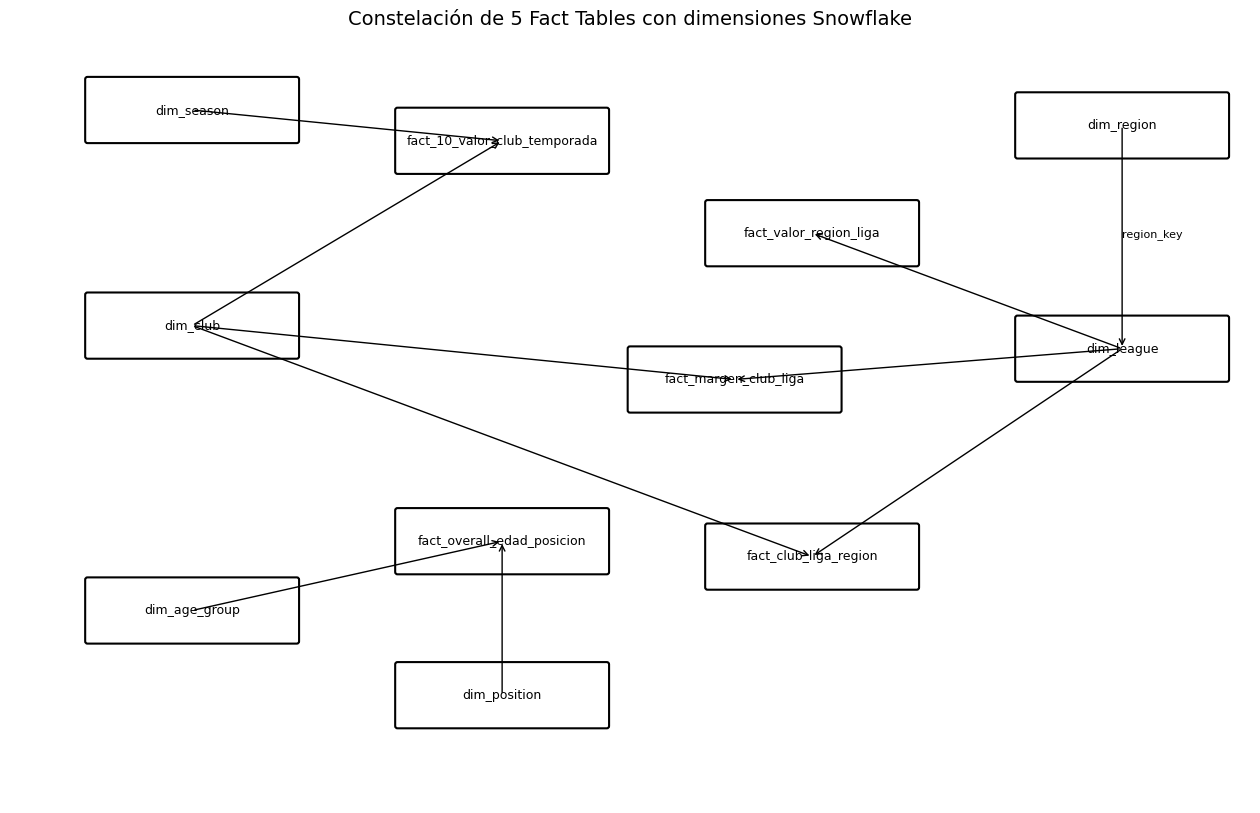

In [80]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

nodos = {
    "dim_season": (1.0, 8.6),
    "dim_club": (1.0, 5.8),
    "dim_age_group": (1.0, 2.1),
    "dim_position": (5.0, 1.0),
    "dim_league": (13.0, 5.5),
    "dim_region": (13.0, 8.4),
    "fact_10_valor_club_temporada": (5.0, 8.2),
    "fact_valor_region_liga": (9.0, 7.0),
    "fact_overall_edad_posicion": (5.0, 3.0),
    "fact_margen_club_liga": (8.0, 5.1),
    "fact_club_liga_region": (9.0, 2.8)
}


def dibujar_nodo(nombre, x, y, ancho=2.7, alto=0.8):
    caja = FancyBboxPatch(
        (x, y), ancho, alto,
        boxstyle="round,pad=0.03",
        fill=False,
        linewidth=1.5
    )
    ax.add_patch(caja)
    ax.text(x + ancho / 2, y + alto / 2, nombre, ha="center", va="center", fontsize=9)


for nombre, (x, y) in nodos.items():
    dibujar_nodo(nombre, x, y)


def centro(nombre):
    x, y = nodos[nombre]
    return x + 1.35, y + 0.4


def conectar(origen, destino, etiqueta=None):
    x1, y1 = centro(origen)
    x2, y2 = centro(destino)
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.0)
    )
    if etiqueta:
        ax.text((x1+x2)/2, (y1+y2)/2, etiqueta, fontsize=8)

# Fact 1
conectar("dim_season", "fact_10_valor_club_temporada")
conectar("dim_club", "fact_10_valor_club_temporada")

# Fact 2
conectar("dim_league", "fact_valor_region_liga")

# Fact 3
conectar("dim_age_group", "fact_overall_edad_posicion")
conectar("dim_position", "fact_overall_edad_posicion")

# Facts 4 y 5
conectar("dim_club", "fact_margen_club_liga")
conectar("dim_league", "fact_margen_club_liga")
conectar("dim_club", "fact_club_liga_region")
conectar("dim_league", "fact_club_liga_region")

# Snowflake
conectar("dim_region", "dim_league", "region_key")

ax.set_title("Constelación de 5 Fact Tables con dimensiones Snowflake", fontsize=14)
plt.show()


# Exportación

Se exportan por separado las dimensiones, las cinco Fact Tables, las cinco consultas y los reportes de validación.

Los archivos de entrada permanecen intactos.


In [81]:
dimensiones_exportar = {
    "dim_season": dim_season,
    "dim_club": dim_club,
    "dim_league": dim_league,
    "dim_region": dim_region,
    "dim_age_group": dim_age_group,
    "dim_position": dim_position
}

facts_exportar = {
    "fact_10_valor_club_temporada": fact_10_valor_club_temporada,
    "fact_valor_region_liga": fact_valor_region_liga,
    "fact_overall_edad_posicion": fact_overall_edad_posicion,
    "fact_margen_club_liga": fact_margen_club_liga,
    "fact_club_liga_region": fact_club_liga_region
}

consultas_exportar = {
    "consulta_1_top10_clubes": consulta_top10_clubes,
    "consulta_2_valor_region_liga": consulta_region_league,
    "consulta_3_overall_edad_posicion": consulta_overall_edad_posicion,
    "consulta_4_margen_club_liga": consulta_margen_club_league,
    "consulta_5_drilldown_club_liga_region": consulta_drilldown
}

for nombre, tabla in dimensiones_exportar.items():
    tabla.to_csv(DIM_DIR / f"{nombre}.csv", index=False)

for nombre, tabla in facts_exportar.items():
    tabla.to_csv(FACT_DIR / f"{nombre}.csv", index=False)

for nombre, tabla in consultas_exportar.items():
    tabla.to_csv(QUERY_DIR / f"{nombre}.csv", index=False)

reporte_carga.to_csv(REPORT_DIR / "reporte_pipeline.csv", index=False)
reporte_validacion_facts.to_csv(REPORT_DIR / "reporte_validacion_facts.csv", index=False)
reporte_tiempos_consultas.to_csv(REPORT_DIR / "reporte_tiempos_consultas.csv", index=False)
auditoria_league_region.to_csv(AUDIT_DIR / "auditoria_league_region.csv", index=False)

print("Dimensiones exportadas:", len(dimensiones_exportar))
print("Fact Tables exportadas:", len(facts_exportar))
print("Consultas exportadas:", len(consultas_exportar))


Dimensiones exportadas: 6
Fact Tables exportadas: 5
Consultas exportadas: 5


## Relectura de entregables

Los CSV se vuelven a leer para comprobar que las claves y granularidades se conservaron después de exportar.


In [82]:
for nombre, tabla in dimensiones_exportar.items():
    releida = pd.read_csv(DIM_DIR / f"{nombre}.csv")
    pd.testing.assert_frame_equal(
        releida,
        tabla.reset_index(drop=True),
        check_dtype=False,
        rtol=1e-9,
        atol=1e-8
    )

for nombre, (tabla, grano) in facts_modelo.items():
    releida = pd.read_csv(FACT_DIR / f"{nombre}.csv")
    pd.testing.assert_frame_equal(
        releida,
        tabla.reset_index(drop=True),
        check_dtype=False,
        rtol=1e-9,
        atol=1e-8
    )
    assert not releida.duplicated(grano).any(), nombre
    assert releida["fact_id"].is_unique, nombre

for nombre, tabla in consultas_exportar.items():
    releida = pd.read_csv(QUERY_DIR / f"{nombre}.csv")
    pd.testing.assert_frame_equal(
        releida,
        tabla.reset_index(drop=True),
        check_dtype=False,
        rtol=1e-9,
        atol=1e-8
    )

# Las dos entradas deben conservar exactamente su hash inicial.
for ruta, huella in huellas_entradas.items():
    assert hashlib.sha256(ruta.read_bytes()).hexdigest() == huella, f"Se modificó la entrada {ruta.name}"

print("Todas las dimensiones, Facts y consultas fueron releídas y validadas")
print("Los archivos de entrada permanecen intactos")


/tmp/ipykernel_3124/3874654763.py:13: FutureWarning: Mismatched null-like values nan and <NA> found. In a future version, pandas equality-testing functions (e.g. assert_frame_equal) will consider these not-matching and raise.
  pd.testing.assert_frame_equal(


Todas las dimensiones, Facts y consultas fueron releídas y validadas
Los archivos de entrada permanecen intactos


## Paquete de resultados

Al terminar la ejecución se genera un ZIP con las salidas de Etapa 2. Este ZIP contiene resultados, no reemplaza los dos archivos de entrada necesarios para volver a ejecutar el notebook.


In [83]:
RUTA_ZIP = BASE_DIR / "resultados_etapa2.zip"

if RUTA_ZIP.exists():
    RUTA_ZIP.unlink()

with zipfile.ZipFile(RUTA_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for ruta in sorted(OUTPUT_DIR.rglob("*")):
        if ruta.is_file():
            zf.write(ruta, ruta.relative_to(BASE_DIR))

print("ZIP generado:", RUTA_ZIP)
print("\nPara reproducir el proyecto desde cero solo se necesitan:")
print("1. Este notebook")
print("2. fifa_15_24_limpio.csv")
print("3. referencias_modelado_etapa2.xlsx")


ZIP generado: /content/Proyecto_FIFA_Etapa2/resultados_etapa2.zip

Para reproducir el proyecto desde cero solo se necesitan:
1. Este notebook
2. fifa_15_24_limpio.csv
3. referencias_modelado_etapa2.xlsx


# Conclusiones

- El modelo ya no utiliza una única Fact Table `player-season`.
- Cada pregunta de negocio tiene una Fact Table con su propia granularidad.
- Las cinco Facts comparten dimensiones, formando una constelación de hechos.
- `League → Region` se modela como Snowflake mediante `dim_league.region_key`.
- `player_id + season` se conserva únicamente como control de integridad y trazabilidad durante la preparación, no como grano del Data Warehouse.
- El pipeline prepara los registros y luego construye las cinco Facts agregadas.
- Cada consulta final se responde desde su Fact Table correspondiente.
- El notebook no depende de Google Drive ni instala dependencias; está preparado para ejecutarse en una sesión limpia de Google Colab.
